<a href="https://colab.research.google.com/github/d4nye1/flight_on_time_mvp_H12-25-L-Equipo33/blob/feature%2Fdata-science/data-science/Optimizando_modelos_NoRNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q gdown optuna catboost lazyPredict

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.7/774.7 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 11.8 MB/s eta 0:00:00


In [2]:
import os
import gc
import time
import warnings
from datetime import timedelta

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, precision_recall_fscore_support, confusion_matrix,
    classification_report, roc_curve, auc, precision_recall_curve,
    average_precision_score
)

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.calibration import CalibratedClassifierCV

from imblearn.under_sampling import RandomUnderSampler

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool

import optuna
import psutil
from lazypredict.Supervised import LazyClassifier

import gdown
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
url = 'https://drive.google.com/file/d/1uCFvcPHO-bchVYWDDtfc7R1Lzr1rSGCI/view?usp=sharing'
url = 'https://drive.google.com/uc?id=' + url.split('/')[-2]

output = 'df_clean_modeling.parquet'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1uCFvcPHO-bchVYWDDtfc7R1Lzr1rSGCI
To: /content/df_clean_modeling.parquet
100%|██████████| 54.3M/54.3M [00:01<00:00, 40.0MB/s]


'df_clean_modeling.parquet'

In [4]:
cleaned_dtset = pd.read_parquet("df_clean_modeling.parquet")

In [5]:
cleaned_dtset.head()

,mes,dia_mes,dia_semana,fin_de_semana,hora_salida,minuto_salida,distancia_millas,tiempo_programado,aerolinea,aeropuerto_origen,aeropuerto_destino,estado_origen,estado_destino,vuelo_retrasado
0,1,1,1,0,12,52,509.00,136.00,9E,JFK,DTW,New York,Michigan,0
1,1,1,1,0,10,15,622.00,130.00,9E,MSP,CLE,Minnesota,Ohio,0
2,1,1,1,0,14,15,288.00,106.00,9E,JFK,RIC,New York,Virginia,0
3,1,1,1,0,16,50,288.00,111.00,9E,RIC,JFK,Virginia,New York,0
4,1,1,1,0,10,15,237.00,79.00,9E,DTW,MKE,Michigan,Wisconsin,0


# Experimentos para mejorar el rendimiento del modelo


1.   Agregar temporalidades trimestrales y estación invernal
2.   Revisar ganacia por tamaño de muestras
3.   Probar metodos adicionales de balanceo
4.   Revisar correlacion
5.   Comparar haciendo tracker de experimentos
6.   Elección de feactures automaticas

In [5]:
def encode_cycle(data, col):
    max_val = data[col].max()

    x = (2 * np.pi * data[col].values / max_val).astype(np.float32)

    data[col + "_sin"] = np.sin(x, dtype=np.float32)
    data[col + "_cos"] = np.cos(x, dtype=np.float32)

    return data

In [6]:
mes = cleaned_dtset["mes"]

cleaned_dtset["trimestre"] = ((mes - 1) // 3) + 1

cleaned_dtset["temporada"] = np.select(
    [
        mes.isin([12, 1, 2]),
        mes.isin([3, 4, 5]),
        mes.isin([6, 7, 8]),
        mes.isin([9, 10, 11])
    ],
    ["invierno", "primavera", "verano", "otoño"],
    default="desconocido"
)

In [ ]:
def etiquetar_barras(ax, formato="{:.1%}"):
    """
    Agrega etiquetas dentro de cada barra de un gráfico de barras
    """
    for bar in ax.patches:
        altura = bar.get_height()
        if altura > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                altura / 2,
                formato.format(altura),
                ha="center",
                va="center",
                fontsize=10
            )

## Evaluando impacto trimestral

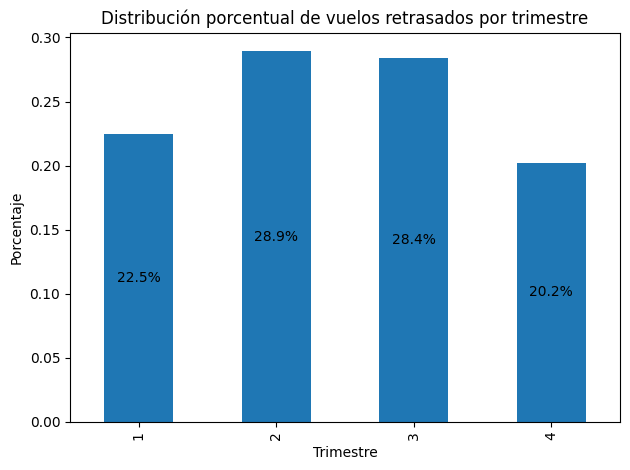

In [ ]:
# Filtrar solo vuelos retrasados
df_delay = cleaned_dtset[cleaned_dtset["vuelo_retrasado"] == 1]

# Distribución porcentual por trimestre
trimestre_pct = (
    df_delay["trimestre"]
    .value_counts(normalize=True)
    .sort_index()
)

# Gráfico
plt.figure()
ax = trimestre_pct.plot(kind="bar")

plt.title("Distribución porcentual de vuelos retrasados por trimestre")
plt.xlabel("Trimestre")
plt.ylabel("Porcentaje")
plt.tight_layout()
etiquetar_barras(ax)
plt.show()

## Evaluando impacto por estación del año

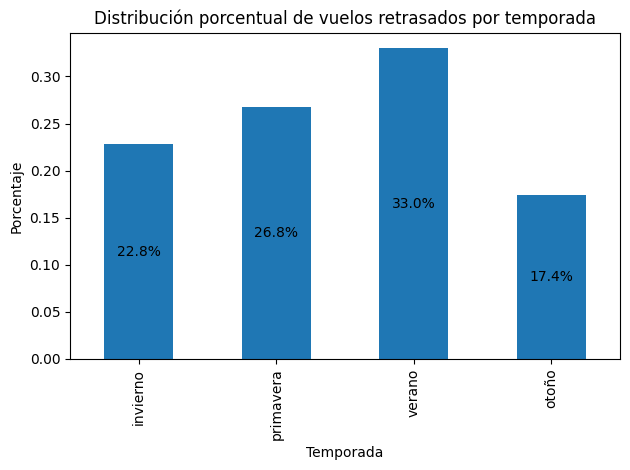

In [ ]:
orden_temporadas = ["invierno", "primavera", "verano", "otoño"]

temporada_pct = (
    df_delay["temporada"]
    .value_counts(normalize=True)
    .reindex(orden_temporadas)
)

# Gráfico
plt.figure()
ax = temporada_pct.plot(kind="bar")

plt.title("Distribución porcentual de vuelos retrasados por temporada")
plt.xlabel("Temporada")
plt.ylabel("Porcentaje")
etiquetar_barras(ax)
plt.tight_layout()
plt.show()

## Convirtiendo variables ciclicas

In [7]:
cyclical_columns = ['mes', 'dia_mes', 'dia_semana', 'hora_salida', 'minuto_salida','trimestre']

for column in cyclical_columns:
  df_clean_v2 = encode_cycle(cleaned_dtset, column)

In [8]:
columns_time = ['mes', 'dia_mes', 'dia_semana', 'hora_salida', 'minuto_salida', 'trimestre']

df_clean_v2.drop(
    columns=[c for c in columns_time if c in df_clean_v2.columns],
    inplace=True
)

## Ubicando la variable 'target' al inicio

In [9]:
target = "vuelo_retrasado"

cols = [target] + [c for c in df_clean_v2.columns if c != target]
df_clean_v2 = df_clean_v2[cols]

## Convirtiendo la columna 'temporada' con OneHotencoding ya que son pocas categorias solo con 4

In [10]:
df_clean_v2 = pd.get_dummies(
    df_clean_v2,
    columns=["temporada"],
    prefix="temporada",
    dtype=int
)

## Evaluando correlación con la variable 'target' --- 'vuelo_retrasado'

In [11]:
corr = df_clean_v2.select_dtypes(include=["number"]).corr()
mi_num_series = corr["vuelo_retrasado"].sort_values(ascending=False)
mi_num_series

,vuelo_retrasado
vuelo_retrasado,1.00
hora_salida_cos,0.09
temporada_verano,0.08
distancia_millas,0.02
tiempo_programado,0.02
mes_sin,0.02
dia_semana_cos,0.02
temporada_primavera,0.02
fin_de_semana,0.02
temporada_invierno,-0.01


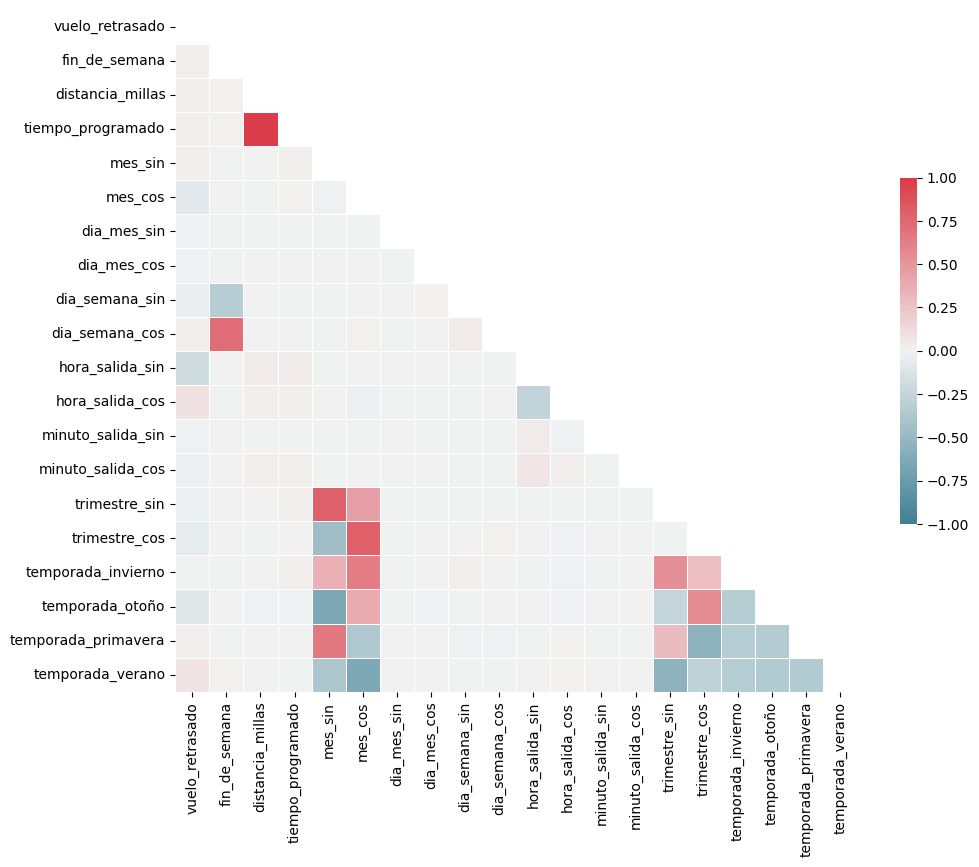

In [ ]:
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

f, ax = plt.subplots(figsize=(11, 9))

cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})


plt.show()

## Se escoge las variables que tengas correlacion mayor a 0.017, en valor absoluto es decir correlación directamente proporcional e inversamente proporcional (este valor puede estar sujeto a corrección)

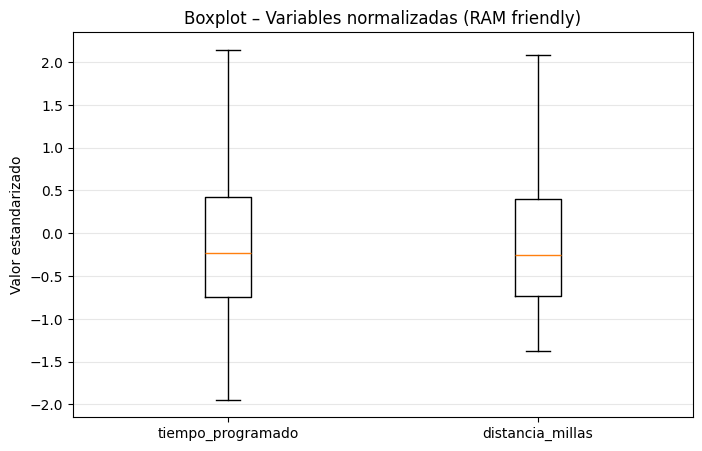

In [13]:
cols = ['tiempo_programado', 'distancia_millas']

X = df_clean_v2[cols].astype("float32", copy=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(8, 5))
plt.boxplot(
    [X_scaled[:, 0], X_scaled[:, 1]],
    labels=cols,
    showfliers=False
)
plt.title("Boxplot – Variables normalizadas (RAM friendly)")
plt.ylabel("Valor estandarizado")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [12]:
selected_num_features =mi_num_series[abs(mi_num_series) > 0.017].index.tolist()
cols_finales = selected_num_features + ['aerolinea','aeropuerto_origen','aeropuerto_destino']

## Se escogen unas columnas finales

In [16]:
cols_finales

['vuelo_retrasado',
 'hora_salida_cos',
 'temporada_verano',
 'distancia_millas',
 'tiempo_programado',
 'mes_sin',
 'dia_semana_cos',
 'temporada_primavera',
 'trimestre_sin',
 'dia_semana_sin',
 'trimestre_cos',
 'mes_cos',
 'temporada_otoño',
 'hora_salida_sin',
 'aerolinea',
 'aeropuerto_origen',
 'aeropuerto_destino']

# Tamaño de muestra

Se hace un primer experimento para determinar el tamaño de muestra optimo para realizar diferentes combinaciones

In [13]:
X = df_clean_v2[cols_finales].drop(columns=['vuelo_retrasado','tiempo_programado'])
y = df_clean_v2['vuelo_retrasado']

In [14]:
numerical_columns = X.select_dtypes(include=['int64', 'float64','float32']).columns
categorical_columns = X.select_dtypes(include=['object']).columns

### Se determina transformaciones para las diferentes columnas

In [19]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_columns),
        ("num",  StandardScaler(), numerical_columns)
    ],
    remainder="drop"
)

## Se usa regresión logistica como base del experimento

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

pipe = Pipeline(
    steps=[
        ("prep", preprocess),
        ("model", model)
    ]
)

## Se realiza muestreos en incrementos de 50 mil registros

In [ ]:
n_values = range(50_000, 500_001, 50_000)
auc_por_n = {}

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

for n in n_values:
    print(f"Entrenando con n = {n}")
    X_n = X_train_full.iloc[:n]
    y_n = y_train_full.iloc[:n]

    pipe.fit(X_n, y_n)

    y_proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    auc_por_n[n] = auc

Entrenando con n = 50000
Entrenando con n = 100000
Entrenando con n = 150000
Entrenando con n = 200000
Entrenando con n = 250000
Entrenando con n = 300000
Entrenando con n = 350000
Entrenando con n = 400000
Entrenando con n = 450000
Entrenando con n = 500000


In [ ]:
auc_df = pd.DataFrame(
    list(auc_por_n.items()),
    columns=["n_registros", "AUC"]
).sort_values("n_registros")

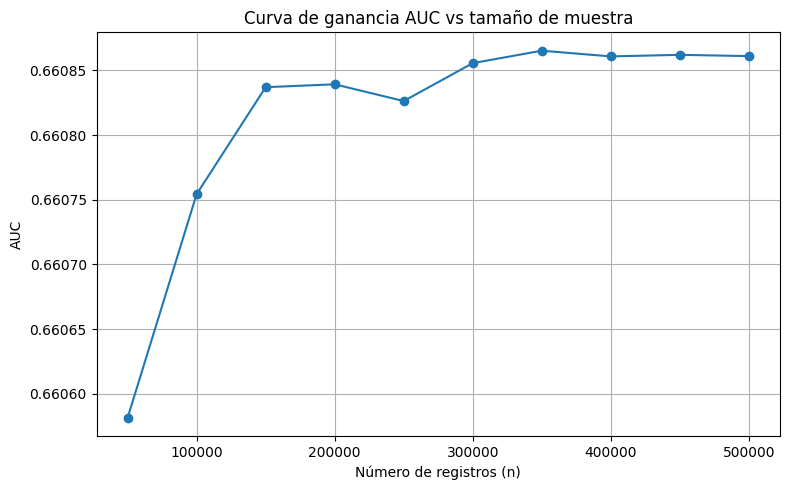

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    auc_df["n_registros"],
    auc_df["AUC"],
    marker="o"
)

plt.xlabel("Número de registros (n)")
plt.ylabel("AUC")
plt.title("Curva de ganancia AUC vs tamaño de muestra")
plt.grid(True)
plt.tight_layout()
plt.show()

## Se determina que despues de 350000 registros la curva AUC no tiene una ganancia significativa

# Balanceo de clases

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=350_000, test_size= 150000, stratify=y, shuffle = True, random_state= 42)

In [ ]:
rus = RandomUnderSampler(random_state = 42, sampling_strategy = 1)

In [ ]:
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

In [ ]:
y_train_rus.value_counts(normalize=True).round(3)

,proportion
vuelo_retrasado,
0,0.50
1,0.50


In [ ]:
X_train_rus_trans = preprocess.fit_transform(X_train_rus).astype(np.float32)
X_test_trans = preprocess.transform(X_test).astype(np.float32)

# Identificando top 5 modelos que mas se ajustan usando LazyClassifier

In [ ]:
clf = LazyClassifier(verbose=1,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(X_train_rus_trans, X_test_trans, y_train_rus, y_test)

In [ ]:
models.head()

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LGBMClassifier,0.62,0.63,0.63,0.66,0.56
SVC,0.61,0.62,0.62,0.65,40.82
XGBClassifier,0.61,0.62,0.62,0.65,0.58
AdaBoostClassifier,0.58,0.62,0.62,0.63,1.65
CalibratedClassifierCV,0.60,0.62,0.62,0.64,0.65


# Modelos a evaluar

*   LGBMClassifier
*   SVC (se descarto por el alto grado computacional) se reemplazo por CalibratedClassifierCV (SGV como base)
*   XGBClassifier
*   AdaBoostClassifier
*   CATboost

# Filtro 1:

Se realiza el experimento con los 5 modelos usando como tamaño de muestra 350000 registros

In [20]:
# @title
class ModelExperiment:
    def __init__(self, X, y, categorical_columns, numerical_columns,
                 n_iterations=5, test_size=0.2, apply_undersampling=True,
                 optimize_memory=True):
        """
        Experimento para comparar múltiples modelos de clasificación

        Parameters:
        -----------
        X : DataFrame
            Features (DataFrame con nombres de columnas)
        y : array-like
            Target variable (0 o 1)
        categorical_columns : list
            Lista de nombres de columnas categóricas
        numerical_columns : list
            Lista de nombres de columnas numéricas
        n_iterations : int
            Número de veces que se ejecuta cada modelo
        test_size : float
            Proporción del conjunto de prueba
        apply_undersampling : bool
            Si True, aplica RandomUnderSampler
        optimize_memory : bool
            Si True, optimiza el uso de memoria RAM
        """
        # Optimizar memoria antes de guardar los datos
        if optimize_memory:
            print("Optimizando uso de memoria...")
            X = self._optimize_dataframe_memory(X, categorical_columns, numerical_columns)
            y = self._optimize_array_memory(y)
            print(f"Memoria optimizada. Uso actual del DataFrame X: {X.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

        self.X = X
        self.y = y
        self.categorical_columns = list(categorical_columns) if not isinstance(categorical_columns, list) else categorical_columns
        self.numerical_columns = list(numerical_columns) if not isinstance(numerical_columns, list) else numerical_columns
        self.n_iterations = n_iterations
        self.test_size = test_size
        self.apply_undersampling = apply_undersampling
        self.results = []

        # Preprocesador para modelos que no manejan categóricas nativas
        self.preprocess = ColumnTransformer(
            transformers=[
                ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
                 categorical_columns),
                ("num", StandardScaler(), numerical_columns)
            ],
            remainder="drop"
        )

        # RandomUnderSampler
        self.rus = RandomUnderSampler(random_state=42, sampling_strategy=1)

        # Definir los modelos (sin random_state aún, se asignará en cada iteración)
        self.models = {
            'CalibratedClassifierCV': {'model': CalibratedClassifierCV, 'needs_preprocessing': True},
            'LGBMClassifier': {'model': LGBMClassifier, 'needs_preprocessing': True},
            'XGBClassifier': {'model': XGBClassifier, 'needs_preprocessing': True},
            'AdaBoostClassifier': {'model': AdaBoostClassifier, 'needs_preprocessing': True},
            'CatBoost': {'model': CatBoostClassifier, 'needs_preprocessing': False}
        }

    def _optimize_dataframe_memory(self, df, categorical_columns, numerical_columns):
        """
        Optimiza el uso de memoria del DataFrame reduciendo tipos de datos

        Returns:
        --------
        DataFrame optimizado
        """
        df = df.copy()

        # Optimizar columnas numéricas
        for col in numerical_columns:
            if col in df.columns:
                col_type = df[col].dtype

                if col_type == 'float64':
                    # Convertir float64 a float32
                    df[col] = df[col].astype('float32')
                elif col_type == 'int64':
                    # Optimizar enteros según rango
                    col_min = df[col].min()
                    col_max = df[col].max()

                    if col_min >= -128 and col_max <= 127:
                        df[col] = df[col].astype('int8')
                    elif col_min >= -32768 and col_max <= 32767:
                        df[col] = df[col].astype('int16')
                    elif col_min >= -2147483648 and col_max <= 2147483647:
                        df[col] = df[col].astype('int32')

        # Optimizar columnas categóricas
        for col in categorical_columns:
            if col in df.columns:
                # Usar tipo 'category' para reducir memoria
                df[col] = df[col].astype('category')

        return df

    def _optimize_array_memory(self, arr):
        """
        Optimiza el uso de memoria de arrays numpy
        """
        if isinstance(arr, pd.Series):
            arr = arr.values

        if arr.dtype == 'float64':
            return arr.astype('float32')
        elif arr.dtype == 'int64':
            arr_min = arr.min()
            arr_max = arr.max()

            if arr_min >= -128 and arr_max <= 127:
                return arr.astype('int8')
            elif arr_min >= -32768 and arr_max <= 32767:
                return arr.astype('int16')
            elif arr_min >= -2147483648 and arr_max <= 2147483647:
                return arr.astype('int32')

        return arr

    def preprocess_data(self, X_train, y_train, X_test, needs_preprocessing, fit_preprocessor=True):
        """
        Preprocesa los datos según el modelo

        Parameters:
        -----------
        X_train, y_train : datos de entrenamiento
        X_test : datos de prueba
        needs_preprocessing : bool
            Si True, aplica ColumnTransformer. Si False (CatBoost), mantiene datos originales
        fit_preprocessor : bool
            Si True, ajusta el preprocesador. Si False, solo transforma
        """
        if needs_preprocessing:
            # Aplicar preprocesamiento para modelos tradicionales
            if fit_preprocessor:
                X_train_processed = self.preprocess.fit_transform(X_train)
            else:
                X_train_processed = self.preprocess.transform(X_train)
            X_test_processed = self.preprocess.transform(X_test)

            # Convertir a float32 para ahorrar memoria
            X_train_processed = X_train_processed.astype('float32')
            X_test_processed = X_test_processed.astype('float32')

            # Aplicar undersampling si está habilitado
            if self.apply_undersampling:
                X_train_processed, y_train = self.rus.fit_resample(X_train_processed, y_train)
                X_train_processed = X_train_processed.astype('float32')  # Mantener float32 después del resample

            return X_train_processed, y_train, X_test_processed
        else:
            # Para CatBoost: mantener datos originales (solo seleccionar columnas relevantes)
            cols_to_keep = self.categorical_columns + self.numerical_columns
            X_train_processed = X_train[cols_to_keep].copy()
            X_test_processed = X_test[cols_to_keep].copy()

            # Aplicar undersampling si está habilitado
            if self.apply_undersampling:
                X_train_processed, y_train = self.rus.fit_resample(X_train_processed, y_train)

            return X_train_processed, y_train, X_test_processed

    def run_experiment(self):
        """Ejecuta el experimento completo"""
        print("="*70)
        print("INICIANDO EXPERIMENTO DE COMPARACIÓN DE MODELOS")
        print("="*70)
        print(f"Balanceo de clases: {'Activado (RandomUnderSampler)' if self.apply_undersampling else 'Desactivado'}")
        print(f"Columnas categóricas: {len(self.categorical_columns)}")
        print(f"Columnas numéricas: {len(self.numerical_columns)}")
        print(f"Distribución original de clases: {dict(pd.Series(self.y).value_counts())}")

        for model_name, model_config in self.models.items():
            print(f"\n{'='*70}")
            print(f"Modelo: {model_name}")
            print(f"Preprocesamiento: {'Sí (ColumnTransformer)' if model_config['needs_preprocessing'] else 'No (CatBoost nativo)'}")
            print(f"{'='*70}")

            for iteration in range(1, self.n_iterations + 1):
                print(f"\nIteración {iteration}/{self.n_iterations}...")

                # Dividir datos con diferentes seeds para cada iteración
                X_train, X_test, y_train, y_test = train_test_split(
                    self.X, self.y,
                    test_size=self.test_size,
                    random_state=iteration,
                    stratify=self.y
                )

                # Preprocesar datos según el modelo
                X_train_processed, y_train_processed, X_test_processed = self.preprocess_data(
                    X_train, y_train, X_test,
                    needs_preprocessing=model_config['needs_preprocessing']
                )

                # Inicializar modelo con parámetros específicos
                if model_name == 'LGBMClassifier':
                    model = model_config['model'](random_state=iteration, verbose=-1)
                elif model_name == 'CalibratedClassifierCV':
                    # CalibratedClassifierCV con LinearSVC como base (más rápido que SVC)
                    base_estimator = LinearSVC(random_state=iteration, max_iter=10000, dual='auto')
                    model = model_config['model'](estimator=base_estimator, cv=3, method='sigmoid')
                elif model_name == 'XGBClassifier':
                    model = model_config['model'](random_state=iteration, eval_metric='logloss')
                elif model_name == 'AdaBoostClassifier':
                    model = model_config['model'](random_state=iteration, algorithm='SAMME')
                elif model_name == 'CatBoost':
                    # CatBoost con columnas categóricas especificadas
                    cat_features_idx = [i for i, col in enumerate(self.categorical_columns + self.numerical_columns)
                                       if col in self.categorical_columns]
                    model = model_config['model'](
                        random_state=iteration,
                        verbose=0,
                        cat_features=cat_features_idx
                    )

                # Entrenar modelo
                model.fit(X_train_processed, y_train_processed)

                # Predicciones
                y_pred = model.predict(X_test_processed)

                # Obtener probabilidades (algunos modelos pueden no tenerlas)
                if hasattr(model, 'predict_proba'):
                    y_pred_proba = model.predict_proba(X_test_processed)[:, 1]
                elif hasattr(model, 'decision_function'):
                    # Para SVC sin probability=True, usar decision_function
                    y_pred_proba = model.decision_function(X_test_processed)
                else:
                    raise AttributeError(f"El modelo {model_name} no tiene predict_proba ni decision_function")

                # Calcular métricas
                auc = roc_auc_score(y_test, y_pred_proba)
                precision, recall, f1, _ = precision_recall_fscore_support(
                    y_test, y_pred, average='binary', pos_label=1
                )

                # Matriz de confusión para clase positiva (CAT=1)
                tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

                # Guardar resultados
                self.results.append({
                    'Modelo': model_name,
                    'Iteración': iteration,
                    'AUC': auc,
                    'Precision_CAT1': precision,
                    'Recall_CAT1': recall,
                    'F1_CAT1': f1,
                    'TP': tp,
                    'FP': fp,
                    'TN': tn,
                    'FN': fn,
                    'Train_Size': len(y_train_processed)
                })

                print(f"  Tamaño entrenamiento (post-balanceo): {len(y_train_processed)}")
                print(f"  AUC: {auc:.4f}")
                print(f"  Precision (CAT=1): {precision:.4f}")
                print(f"  Recall (CAT=1): {recall:.4f}")
                print(f"  F1-Score (CAT=1): {f1:.4f}")

                # Liberar memoria explícitamente
                del model, X_train_processed, y_train_processed, X_test_processed
                del y_pred, y_pred_proba, X_train, X_test, y_train, y_test
                gc.collect()

        return pd.DataFrame(self.results)

    def get_memory_usage(self):
        """Muestra el uso actual de memoria del experimento"""
        import psutil
        import os

        process = psutil.Process(os.getpid())
        mem_info = process.memory_info()

        print(f"\n{'='*70}")
        print("USO DE MEMORIA")
        print(f"{'='*70}")
        print(f"Memoria RAM utilizada: {mem_info.rss / 1024**2:.2f} MB")
        print(f"Memoria del DataFrame X: {self.X.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        print(f"Memoria del array y: {self.y.nbytes / 1024**2:.2f} MB")
        print(f"{'='*70}")

    def analyze_results(self, results_df):
        """Analiza y visualiza los resultados"""
        print("\n" + "="*70)
        print("RESUMEN DE RESULTADOS")
        print("="*70)

        # Estadísticas por modelo
        summary = results_df.groupby('Modelo').agg({
            'AUC': ['mean', 'std', 'min', 'max'],
            'Precision_CAT1': ['mean', 'std'],
            'Recall_CAT1': ['mean', 'std'],
            'F1_CAT1': ['mean', 'std']
        }).round(4)

        print("\n", summary)

        # Encontrar el mejor modelo por AUC
        auc_means = results_df.groupby('Modelo')['AUC'].mean()
        best_by_auc = auc_means.idxmax()
        best_auc_value = auc_means.max()

        print(f"\n{'='*70}")
        print(f"🏆 MEJOR MODELO POR AUC: {best_by_auc}")
        print(f"   AUC Promedio: {best_auc_value:.4f} ± {results_df[results_df['Modelo']==best_by_auc]['AUC'].std():.4f}")
        print(f"{'='*70}")

        # Mejor modelo por F1 para CAT=1
        f1_means = results_df.groupby('Modelo')['F1_CAT1'].mean()
        best_by_f1 = f1_means.idxmax()
        best_f1_value = f1_means.max()

        print(f"\n🏆 MEJOR MODELO POR F1-SCORE (CAT=1): {best_by_f1}")
        print(f"   F1-Score Promedio: {best_f1_value:.4f} ± {results_df[results_df['Modelo']==best_by_f1]['F1_CAT1'].std():.4f}")
        print(f"{'='*70}")

        # Ranking general
        print("\n📊 RANKING GENERAL (promedio de rankings):")
        ranking_df = pd.DataFrame({
            'AUC_rank': auc_means.rank(ascending=False),
            'F1_rank': f1_means.rank(ascending=False),
            'Precision_rank': results_df.groupby('Modelo')['Precision_CAT1'].mean().rank(ascending=False),
            'Recall_rank': results_df.groupby('Modelo')['Recall_CAT1'].mean().rank(ascending=False)
        })
        ranking_df['Ranking_Promedio'] = ranking_df.mean(axis=1)
        ranking_df = ranking_df.sort_values('Ranking_Promedio')
        print(ranking_df)

        return summary, best_by_auc, best_by_f1

    def plot_results(self, results_df):
        """Genera visualizaciones de los resultados"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Comparación de Modelos - Experimento con 5 Iteraciones',
                     fontsize=16, fontweight='bold')

        # 1. Boxplot de AUC
        ax1 = axes[0, 0]
        results_df.boxplot(column='AUC', by='Modelo', ax=ax1)
        ax1.set_title('Distribución de AUC por Modelo')
        ax1.set_xlabel('Modelo')
        ax1.set_ylabel('AUC')
        ax1.get_figure().suptitle('')
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

        # 2. Barplot de AUC promedio con barras de error
        ax2 = axes[0, 1]
        auc_summary = results_df.groupby('Modelo')['AUC'].agg(['mean', 'std'])
        auc_summary['mean'].plot(kind='bar', ax=ax2, yerr=auc_summary['std'],
                                  capsize=5, color='skyblue', edgecolor='black')
        ax2.set_title('AUC Promedio por Modelo (± std)')
        ax2.set_xlabel('Modelo')
        ax2.set_ylabel('AUC Promedio')
        ax2.axhline(y=0.5, color='r', linestyle='--', alpha=0.3, label='Random')
        ax2.legend()
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

        # 3. Métricas para CAT=1
        ax3 = axes[1, 0]
        metrics_summary = results_df.groupby('Modelo')[
            ['Precision_CAT1', 'Recall_CAT1', 'F1_CAT1']
        ].mean()
        metrics_summary.plot(kind='bar', ax=ax3, width=0.8)
        ax3.set_title('Métricas Promedio para Clase Positiva (CAT=1)')
        ax3.set_xlabel('Modelo')
        ax3.set_ylabel('Score')
        ax3.legend(['Precision', 'Recall', 'F1-Score'])
        ax3.set_ylim([0, 1])
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

        # 4. Heatmap de rankings
        ax4 = axes[1, 1]
        ranking_data = pd.DataFrame({
            'AUC': results_df.groupby('Modelo')['AUC'].mean().rank(ascending=False),
            'Precision': results_df.groupby('Modelo')['Precision_CAT1'].mean().rank(ascending=False),
            'Recall': results_df.groupby('Modelo')['Recall_CAT1'].mean().rank(ascending=False),
            'F1': results_df.groupby('Modelo')['F1_CAT1'].mean().rank(ascending=False)
        })
        sns.heatmap(ranking_data, annot=True, fmt='.0f', cmap='RdYlGn_r',
                    ax=ax4, cbar_kws={'label': 'Ranking (1=Mejor)'})
        ax4.set_title('Ranking de Modelos por Métrica')
        ax4.set_xlabel('Métrica')
        ax4.set_ylabel('Modelo')

        plt.tight_layout()
        plt.show()

## Resultados filtro 1:




Tipos de datos ANTES de optimización:
float32    8
int64      3
object     3
float64    1
Name: count, dtype: int64
Memoria ANTES: 75.77 MB
Optimizando uso de memoria...
Memoria optimizada. Uso actual del DataFrame X: 17.41 MB

Tipos de datos DESPUÉS de optimización:
float32     9
int8        3
category    2
category    1
Name: count, dtype: int64

USO DE MEMORIA
Memoria RAM utilizada: 5114.91 MB
Memoria del DataFrame X: 17.41 MB
Memoria del array y: 0.33 MB
INICIANDO EXPERIMENTO DE COMPARACIÓN DE MODELOS
Balanceo de clases: Activado (RandomUnderSampler)
Columnas categóricas: 3
Columnas numéricas: 12
Distribución original de clases: {0: np.int64(280209), 1: np.int64(69791)}

Modelo: CalibratedClassifierCV
Preprocesamiento: Sí (ColumnTransformer)

Iteración 1/5...
  Tamaño entrenamiento (post-balanceo): 97708
  AUC: 0.6572
  Precision (CAT=1): 0.2796
  Recall (CAT=1): 0.6469
  F1-Score (CAT=1): 0.3904

Iteración 2/5...
  Tamaño entrenamiento (post-balanceo): 97708
  AUC: 0.6600
  Preci

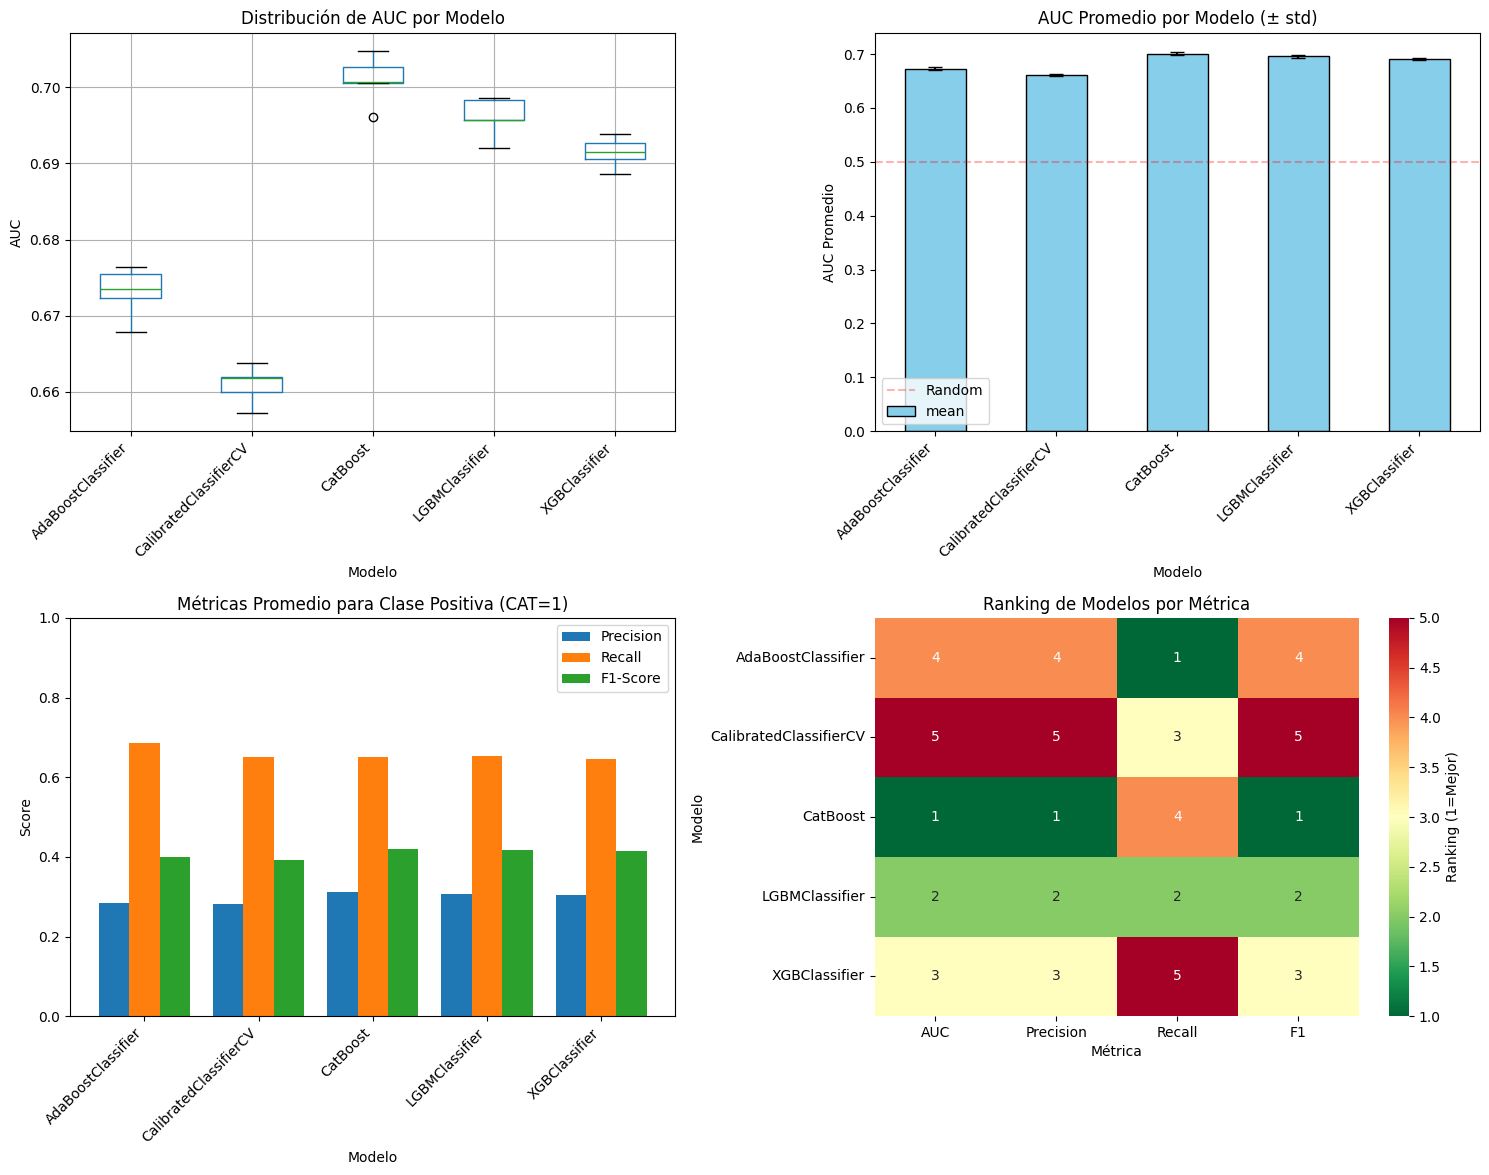


Guardando resultados en 'experiment_results.csv'...

USO DE MEMORIA
Memoria RAM utilizada: 5329.61 MB
Memoria del DataFrame X: 17.41 MB
Memoria del array y: 0.33 MB

✅ Experimento completado!


In [21]:
if __name__ == "__main__":

    X_e, _, y_e, _ = train_test_split(X, y, train_size=350_000, test_size= 150000, stratify=y, shuffle = True, random_state= 42)

    numerical_columns = X.select_dtypes(include=['int64', 'float64','float32']).columns
    categorical_columns = X.select_dtypes(include=['object']).columns

    print(f"\nTipos de datos ANTES de optimización:")
    print(X_e.dtypes.value_counts())
    print(f"Memoria ANTES: {X_e.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # Crear y ejecutar experimento con optimización de memoria ACTIVADA
    experiment = ModelExperiment(
        X=X_e,
        y=y_e,
        categorical_columns=categorical_columns,
        numerical_columns=numerical_columns,
        n_iterations=5,
        test_size=0.3,
        apply_undersampling=True,  # Activar balanceo
        optimize_memory=True  # ACTIVAR OPTIMIZACIÓN DE MEMORIA
    )

    print(f"\nTipos de datos DESPUÉS de optimización:")
    print(experiment.X.dtypes.value_counts())

    # Mostrar uso de memoria
    experiment.get_memory_usage()

    # Ejecutar experimento
    results_df = experiment.run_experiment()

    # Analizar resultados
    summary, best_auc, best_f1 = experiment.analyze_results(results_df)

    # Visualizar resultados
    experiment.plot_results(results_df)

    # Guardar resultados
    print("\nGuardando resultados en 'experiment_results.csv'...")
    results_df.to_csv('experiment_results.csv', index=False)

    # Mostrar uso final de memoria
    experiment.get_memory_usage()

    print("\n✅ Experimento completado!")


# Filtro 2:

Optimizando hyperparametros

Modelos que pasaron a la siguiente etapa:

* Catboost
* LGBMClassifier
* XGBClassifier

## Resultados filtro 2:

Se evalua dos metodos de optimización

*   Random Grid Search
*   Optuna

### 1. Random Grid Search

In [ ]:
# @title
class HyperparameterTuning:
    def __init__(self, X, y, categorical_columns, numerical_columns,
                 test_size=0.2, apply_undersampling=True):
        """
        Optimización de hiperparámetros para los 3 mejores modelos

        Parameters:
        -----------
        X : DataFrame
            Features
        y : array-like
            Target (0 o 1)
        categorical_columns : list
            Columnas categóricas
        numerical_columns : list
            Columnas numéricas
        test_size : float
            Proporción del conjunto de prueba
        apply_undersampling : bool
            Si True, aplica RandomUnderSampler
        """
        self.X = X
        self.y = y
        self.categorical_columns = list(categorical_columns) if not isinstance(categorical_columns, list) else categorical_columns
        self.numerical_columns = list(numerical_columns) if not isinstance(numerical_columns, list) else numerical_columns
        self.test_size = test_size
        self.apply_undersampling = apply_undersampling

        # Preprocesador
        self.preprocess = ColumnTransformer(
            transformers=[
                ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
                 categorical_columns),
                ("num", StandardScaler(), numerical_columns)
            ],
            remainder="drop"
        )

        # RandomUnderSampler
        self.rus = RandomUnderSampler(random_state=42, sampling_strategy=1)

        # Resultados
        self.results = {}

    def get_param_distributions(self):
        """Define los espacios de búsqueda de hiperparámetros"""
        param_distributions = {
            'LGBMClassifier': {
                'n_estimators': [50, 100, 200, 300],
                'max_depth': [3, 5, 7, 10, -1],
                'learning_rate': [0.01, 0.05, 0.1, 0.2],
                'num_leaves': [15, 31, 50, 70],
                'min_child_samples': [10, 20, 30, 50],
                'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
                'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
            },
            'XGBClassifier': {
                'n_estimators': [50, 100, 200, 300],
                'max_depth': [3, 5, 7, 10],
                'learning_rate': [0.01, 0.05, 0.1, 0.2],
                'min_child_weight': [1, 3, 5, 7],
                'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
                'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
                'gamma': [0, 0.1, 0.2, 0.3]
            },
            'CatBoost': {
                'iterations': [50, 100, 200, 300],
                'depth': [4, 6, 8, 10],
                'learning_rate': [0.01, 0.05, 0.1, 0.2],
                'l2_leaf_reg': [1, 3, 5, 7, 9],
                'border_count': [32, 64, 128],
                'bagging_temperature': [0, 0.5, 1.0]
            }
        }
        return param_distributions

    def optimize_model(self, model_name, model_class, param_dist,
                       X_train, y_train, cat_features_idx=None):
        """
        Optimiza un modelo usando RandomizedSearchCV

        Parameters:
        -----------
        model_name : str
            Nombre del modelo
        model_class : class
            Clase del modelo
        param_dist : dict
            Distribución de parámetros
        X_train, y_train : arrays
            Datos de entrenamiento
        cat_features_idx : list
            Índices de features categóricas (solo para CatBoost)
        """
        print(f"\n{'='*70}")
        print(f"Optimizando {model_name}...")
        print(f"{'='*70}")

        # VALIDACIÓN 1: Verificar NaN en datos
        if hasattr(X_train, 'isnull'):
            nan_count = X_train.isnull().sum().sum()
        else:
            nan_count = np.isnan(X_train).sum()

        if nan_count > 0:
            print(f"⚠️  ADVERTENCIA: Se encontraron {nan_count} valores NaN en X_train")
            print("   Rellenando NaN con 0...")
            if hasattr(X_train, 'fillna'):
                X_train = X_train.fillna(0)
            else:
                X_train = np.nan_to_num(X_train, nan=0.0)

        y_train_nan = np.isnan(y_train).sum() if hasattr(y_train, 'sum') else 0
        if y_train_nan > 0:
            print(f"⚠️  ERROR: Se encontraron {y_train_nan} valores NaN en y_train")
            return None

        # VALIDACIÓN 2: Verificar distribución de clases
        unique, counts = np.unique(y_train, return_counts=True)
        class_distribution = dict(zip(unique, counts))
        print(f"Distribución de clases en entrenamiento: {class_distribution}")

        if len(unique) < 2:
            print(f"⚠️  ERROR: Solo hay {len(unique)} clase(s) en los datos de entrenamiento")
            return None

        min_class_count = min(counts)
        if min_class_count < 3:
            print(f"⚠️  ERROR: La clase minoritaria tiene solo {min_class_count} muestras (mínimo 3 para CV)")
            return None

        start_time = time.time()

        # Inicializar modelo base
        if model_name == 'LGBMClassifier':
            base_model = model_class(random_state=42, verbose=-1)
        elif model_name == 'XGBClassifier':
            base_model = model_class(random_state=42, eval_metric='logloss', verbosity=0)
        elif model_name == 'CatBoost':
            base_model = model_class(
                random_state=42,
                verbose=0,
                cat_features=cat_features_idx if cat_features_idx else []
            )

        # Scorer personalizado con manejo de errores
        def safe_roc_auc_scorer(y_true, y_pred_proba):
            try:
                # Verificar que haya ambas clases
                if len(np.unique(y_true)) < 2:
                    print("⚠️  Fold tiene solo una clase, retornando 0.5")
                    return 0.5

                # Verificar NaN en predicciones
                if np.any(np.isnan(y_pred_proba)):
                    print("⚠️  Predicciones contienen NaN, retornando 0.5")
                    return 0.5

                score = roc_auc_score(y_true, y_pred_proba)

                # Verificar si el score es válido
                if np.isnan(score) or np.isinf(score):
                    print(f"⚠️  Score inválido: {score}, retornando 0.5")
                    return 0.5

                return score
            except Exception as e:
                print(f"⚠️  Error calculando AUC: {e}, retornando 0.5")
                return 0.5

        scorer = make_scorer(safe_roc_auc_scorer)

        # RandomizedSearchCV con configuración eficiente en RAM
        random_search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_dist,
            n_iter=15,  # Solo 15 combinaciones aleatorias (eficiente)
            cv=3,       # 3-fold CV (menos que 5, ahorra RAM)
            scoring=scorer, #make_scorer(roc_auc_score, needs_proba=True),
            n_jobs=1,   # 1 job a la vez (menos RAM)
            random_state=42,
            verbose=1
        )

        # Entrenar
        random_search.fit(X_train, y_train)

        elapsed_time = time.time() - start_time

        # Guardar resultados
        self.results[model_name] = {
            'best_params': random_search.best_params_,
            'best_score': random_search.best_score_,
            'best_estimator': random_search.best_estimator_,
            'cv_results': pd.DataFrame(random_search.cv_results_),
            'time_seconds': elapsed_time
        }

        print(f"\n✅ Optimización completada en {timedelta(seconds=int(elapsed_time))}")
        print(f"Mejor AUC (CV): {random_search.best_score_:.4f}")
        print(f"\nMejores hiperparámetros:")
        for param, value in random_search.best_params_.items():
            print(f"  {param}: {value}")

        return random_search.best_estimator_

    def run_optimization(self):
        """Ejecuta la optimización completa"""
        print("="*70)
        print("OPTIMIZACIÓN DE HIPERPARÁMETROS - TOP 3 MODELOS")
        print("="*70)
        print(f"Método: RandomizedSearchCV (15 iteraciones, 3-fold CV)")
        print(f"Configuración RAM-eficiente: n_jobs=1")
        print(f"Balanceo de clases: {'Activado' if self.apply_undersampling else 'Desactivado'}")

        # Split datos
        X_train, X_test, y_train, y_test = train_test_split(
            self.X, self.y,
            test_size=self.test_size,
            random_state=42,
            stratify=self.y
        )

        print(f"\nTamaño entrenamiento: {len(X_train)}")
        print(f"Tamaño prueba: {len(X_test)}")

        # Obtener distribuciones de parámetros
        param_distributions = self.get_param_distributions()

        # ========== LGBM y XGBoost (requieren preprocesamiento) ==========
        print("\n" + "="*70)
        print("PREPROCESANDO DATOS PARA LGBM Y XGBOOST")
        print("="*70)

        X_train_processed = self.preprocess.fit_transform(X_train).astype('float32')
        X_test_processed = self.preprocess.transform(X_test).astype('float32')

        if self.apply_undersampling:
            X_train_processed, y_train_balanced = self.rus.fit_resample(X_train_processed, y_train)
            X_train_processed = X_train_processed.astype('float32')
        else:
            y_train_balanced = y_train

        print(f"Tamaño post-balanceo: {len(y_train_balanced)}")

        # Optimizar LGBM
        best_lgbm = self.optimize_model(
            'LGBMClassifier',
            LGBMClassifier,
            param_distributions['LGBMClassifier'],
            X_train_processed,
            y_train_balanced
        )

        # Optimizar XGBoost
        best_xgb = self.optimize_model(
            'XGBClassifier',
            XGBClassifier,
            param_distributions['XGBClassifier'],
            X_train_processed,
            y_train_balanced
        )

        # ========== CatBoost (sin preprocesamiento) ==========
        print("\n" + "="*70)
        print("PREPARANDO DATOS PARA CATBOOST (SIN PREPROCESAMIENTO)")
        print("="*70)

        cols_to_keep = self.categorical_columns + self.numerical_columns
        X_train_cat = X_train[cols_to_keep].copy()
        X_test_cat = X_test[cols_to_keep].copy()

        if self.apply_undersampling:
            X_train_cat, y_train_cat = self.rus.fit_resample(X_train_cat, y_train)
        else:
            y_train_cat = y_train

        cat_features_idx = [i for i, col in enumerate(cols_to_keep)
                           if col in self.categorical_columns]

        # Optimizar CatBoost
        best_catboost = self.optimize_model(
            'CatBoost',
            CatBoostClassifier,
            param_distributions['CatBoost'],
            X_train_cat,
            y_train_cat,
            cat_features_idx=cat_features_idx
        )

        # ========== EVALUACIÓN FINAL EN TEST SET ==========
        print("\n" + "="*70)
        print("EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA")
        print("="*70)

        test_results = {}

        # LGBM
        y_pred_proba_lgbm = best_lgbm.predict_proba(X_test_processed)[:, 1]
        auc_lgbm = roc_auc_score(y_test, y_pred_proba_lgbm)
        test_results['LGBMClassifier'] = auc_lgbm
        print(f"LGBMClassifier - AUC en Test: {auc_lgbm:.4f}")

        # XGBoost
        y_pred_proba_xgb = best_xgb.predict_proba(X_test_processed)[:, 1]
        auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
        test_results['XGBClassifier'] = auc_xgb
        print(f"XGBClassifier  - AUC en Test: {auc_xgb:.4f}")

        # CatBoost
        y_pred_proba_cat = best_catboost.predict_proba(X_test_cat)[:, 1]
        auc_cat = roc_auc_score(y_test, y_pred_proba_cat)
        test_results['CatBoost'] = auc_cat
        print(f"CatBoost       - AUC en Test: {auc_cat:.4f}")

        # Mejor modelo
        best_model_name = max(test_results, key=test_results.get)
        print(f"\n{'='*70}")
        print(f"🏆 MEJOR MODELO: {best_model_name}")
        print(f"   AUC en Test: {test_results[best_model_name]:.4f}")
        print(f"{'='*70}")

        return self.results, test_results

    def get_summary_table(self):
        """Genera tabla resumen de los resultados"""
        summary_data = []
        for model_name, result in self.results.items():
            summary_data.append({
                'Modelo': model_name,
                'Mejor_AUC_CV': result['best_score'],
                'Tiempo_seg': result['time_seconds'],
                'Tiempo_formato': str(timedelta(seconds=int(result['time_seconds'])))
            })

        df_summary = pd.DataFrame(summary_data).sort_values('Mejor_AUC_CV', ascending=False)
        return df_summary



In [ ]:
if __name__ == "__main__":

    X_e, _, y_e, _ = train_test_split(X, y, train_size=750_000, test_size= 322_000, stratify=y, shuffle = True, random_state= 42)

    numerical_columns = X.select_dtypes(include=['int64', 'float64','float32']).columns
    categorical_columns = X.select_dtypes(include=['object']).columns

    # Crear y ejecutar optimización
    tuning = HyperparameterTuning(
        X=X_e,
        y=y_e,
        categorical_columns=categorical_columns,
        numerical_columns=numerical_columns,
        test_size=0.3,
        apply_undersampling=True
    )

    # Ejecutar optimización
    results, test_results = tuning.run_optimization()

    # Mostrar tabla resumen
    print("\n" + "="*70)
    print("TABLA RESUMEN")
    print("="*70)
    summary_table = tuning.get_summary_table()
    print(summary_table.to_string(index=False))

    # Guardar mejores modelos
    print("\n💾 Guardando mejores hiperparámetros...")

    for model_name in results.keys():
        filename = f'best_params_{model_name}.txt'
        with open(filename, 'w') as f:
            f.write(f"Mejores hiperparámetros para {model_name}\n")
            f.write("="*50 + "\n\n")
            for param, value in results[model_name]['best_params'].items():
                f.write(f"{param}: {value}\n")
            f.write(f"\nMejor AUC (CV): {results[model_name]['best_score']:.4f}\n")
        print(f"  ✓ {filename}")

    print("\n✅ Optimización completada!")

OPTIMIZACIÓN DE HIPERPARÁMETROS - TOP 3 MODELOS
Método: RandomizedSearchCV (15 iteraciones, 3-fold CV)
Configuración RAM-eficiente: n_jobs=1
Balanceo de clases: Activado

Tamaño entrenamiento: 525000
Tamaño prueba: 225000

PREPROCESANDO DATOS PARA LGBM Y XGBOOST
Tamaño post-balanceo: 209372

Optimizando LGBMClassifier...
Distribución de clases en entrenamiento: {np.int64(0): np.int64(104686), np.int64(1): np.int64(104686)}
Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ Optimización completada en 0:03:19
Mejor AUC (CV): 0.6465

Mejores hiperparámetros:
  subsample: 0.6
  num_leaves: 50
  n_estimators: 200
  min_child_samples: 30
  max_depth: 7
  learning_rate: 0.1
  colsample_bytree: 0.8

Optimizando XGBClassifier...
Distribución de clases en entrenamiento: {np.int64(0): np.int64(104686), np.int64(1): np.int64(104686)}
Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ Optimización completada en 0:02:31
Mejor AUC (CV): 0.6451

Mejores hiperparámetros:
  sub

### 2. Optuna

In [22]:
# @title
class OptunaHyperparameterTuning:
    def __init__(self, X, y, categorical_columns, numerical_columns,
                 test_size=0.2, tune_fraction=0.15, apply_undersampling=True,
                 random_state=42):
        """
        Optimización de hiperparámetros usando Optuna para los 3 mejores modelos

        Parameters:
        -----------
        X : DataFrame
            Features
        y : array-like
            Target (0 o 1)
        categorical_columns : list
            Columnas categóricas
        numerical_columns : list
            Columnas numéricas
        test_size : float
            Proporción del conjunto de prueba
        tune_fraction : float
            Fracción del training set para tuning (0.15 = 15% para ahorrar RAM)
        apply_undersampling : bool
            Si True, aplica RandomUnderSampler
        random_state : int
            Semilla aleatoria
        """
        self.random_state = random_state
        self.X = X
        self.y = y
        self.categorical_columns = list(categorical_columns) if not isinstance(categorical_columns, list) else categorical_columns
        self.numerical_columns = list(numerical_columns) if not isinstance(numerical_columns, list) else numerical_columns
        self.test_size = test_size
        self.tune_fraction = tune_fraction
        self.apply_undersampling = apply_undersampling

        # Preprocesador
        self.preprocess = ColumnTransformer(
            transformers=[
                ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
                 categorical_columns),
                ("num", StandardScaler(), numerical_columns)
            ],
            remainder="drop"
        )

        # RandomUnderSampler
        self.rus = RandomUnderSampler(random_state=random_state, sampling_strategy=1)

        # Resultados
        self.results = []
        self.best_models = {}

    def _measure_resources(self, func):
        """Mide tiempo y memoria RAM usada"""
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024**2
        start = time.time()

        result = func()

        elapsed = time.time() - start
        mem_after = process.memory_info().rss / 1024**2

        return result, elapsed, mem_after - mem_before

    def prepare_data(self):
        """Prepara los datos: split, preprocesamiento y subsampling para tuning"""
        print("="*70)
        print("PREPARACIÓN DE DATOS")
        print("="*70)

        # Split train/test
        X_train, X_test, y_train, y_test = train_test_split(
            self.X, self.y,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=self.y
        )

        # Asegurar que y_test sea array numpy
        y_test = np.array(y_test)

        print(f"Train original: {len(X_train)} muestras")
        print(f"Test: {len(X_test)} muestras")

        # ===== Para LGBM y XGBoost (requieren preprocesamiento) =====
        X_train_processed = self.preprocess.fit_transform(X_train).astype('float32')
        X_test_processed = self.preprocess.transform(X_test).astype('float32')

        if self.apply_undersampling:
            X_train_processed, y_train_processed = self.rus.fit_resample(X_train_processed, y_train)
            X_train_processed = X_train_processed.astype('float32')
            y_train_processed = np.array(y_train_processed)  # Asegurar que sea array
        else:
            y_train_processed = np.array(y_train)

        print(f"Train balanceado: {len(y_train_processed)} muestras")

        # Subsample para tuning (ahorro de RAM y velocidad)
        n_tune = int(len(X_train_processed) * self.tune_fraction)
        idx_tune = np.random.RandomState(self.random_state).choice(
            len(X_train_processed), n_tune, replace=False
        )

        # Crear conjunto de validación (del resto)
        idx_all = np.arange(len(X_train_processed))
        idx_val = np.setdiff1d(idx_all, idx_tune)

        X_tune = X_train_processed[idx_tune]
        y_tune = y_train_processed[idx_tune]
        X_val = X_train_processed[idx_val]
        y_val = y_train_processed[idx_val]

        print(f"Tune subset: {len(y_tune)} muestras ({self.tune_fraction*100:.0f}%)")
        print(f"Validation: {len(y_val)} muestras")

        # ===== Para CatBoost (sin preprocesamiento) =====
        cols_to_keep = self.categorical_columns + self.numerical_columns
        X_train_cat = X_train[cols_to_keep].copy()
        X_test_cat = X_test[cols_to_keep].copy()

        if self.apply_undersampling:
            X_train_cat, y_train_cat = self.rus.fit_resample(X_train_cat, y_train)
            # IMPORTANTE: Resetear índice después de resample
            X_train_cat = X_train_cat.reset_index(drop=True)
            y_train_cat = np.array(y_train_cat)  # Asegurar que sea array
        else:
            y_train_cat = np.array(y_train)
            X_train_cat = X_train_cat.reset_index(drop=True)

        # Subsample para CatBoost
        idx_tune_cat = np.random.RandomState(self.random_state).choice(
            len(X_train_cat), int(len(X_train_cat) * self.tune_fraction), replace=False
        )
        idx_all_cat = np.arange(len(X_train_cat))
        idx_val_cat = np.setdiff1d(idx_all_cat, idx_tune_cat)

        X_tune_cat = X_train_cat.iloc[idx_tune_cat].reset_index(drop=True)
        y_tune_cat = y_train_cat[idx_tune_cat]
        X_val_cat = X_train_cat.iloc[idx_val_cat].reset_index(drop=True)
        y_val_cat = y_train_cat[idx_val_cat]

        cat_features_idx = [i for i, col in enumerate(cols_to_keep)
                           if col in self.categorical_columns]

        # Guardar todo
        self.data = {
            'lgbm_xgb': {
                'X_tune': X_tune,
                'y_tune': y_tune,
                'X_val': X_val,
                'y_val': y_val,
                'X_test': X_test_processed,
                'y_test': y_test
            },
            'catboost': {
                'X_tune': X_tune_cat,
                'y_tune': y_tune_cat,
                'X_val': X_val_cat,
                'y_val': y_val_cat,
                'X_test': X_test_cat,
                'y_test': y_test,
                'cat_features_idx': cat_features_idx
            }
        }

        print("✅ Datos preparados")

    # ============================================================================
    # OPTIMIZACIÓN LGBM
    # ============================================================================
    def optimize_lgbm(self, n_trials=30):
        """Optimiza LGBMClassifier usando Optuna"""
        print(f"\n{'='*70}")
        print("OPTIMIZANDO LGBMClassifier")
        print(f"{'='*70}")
        print(f"Trials: {n_trials}")

        data = self.data['lgbm_xgb']

        def objective(trial):
            params = {
                "n_estimators": 500,
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "num_leaves": trial.suggest_int("num_leaves", 31, 128),
                "max_depth": trial.suggest_int("max_depth", 3, 10),
                "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
                "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0),
                "random_state": self.random_state,
                "verbose": -1,
                "n_jobs": -1
            }

            model = LGBMClassifier(**params)
            model.fit(data['X_tune'], data['y_tune'])

            preds = model.predict_proba(data['X_val'])[:, 1]
            return roc_auc_score(data['y_val'], preds)

        study = optuna.create_study(direction="maximize")

        def run():
            study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
            return study.best_value

        best_auc, elapsed_time, ram_mb = self._measure_resources(run)

        # Entrenar modelo final con mejores parámetros
        best_params = study.best_params
        best_params.update({
            "n_estimators": 500,
            "random_state": self.random_state,
            "verbose": -1,
            "n_jobs": -1
        })

        final_model = LGBMClassifier(**best_params)
        # Entrenar con TODOS los datos de entrenamiento (no solo tune)
        X_train_full = np.vstack([data['X_tune'], data['X_val']])
        y_train_full = np.concatenate([data['y_tune'], data['y_val']])
        final_model.fit(X_train_full, y_train_full)

        # Evaluar en test
        y_pred_proba = final_model.predict_proba(data['X_test'])[:, 1]
        test_auc = roc_auc_score(data['y_test'], y_pred_proba)

        self.results.append({
            "model": "LGBMClassifier",
            "auc_val": best_auc,
            "auc_test": test_auc,
            "time_sec": elapsed_time,
            "ram_mb": ram_mb,
            "best_params": study.best_params
        })

        self.best_models['LGBMClassifier'] = final_model

        print(f"✅ Completado en {timedelta(seconds=int(elapsed_time))}")
        print(f"   AUC Validación: {best_auc:.4f}")
        print(f"   AUC Test: {test_auc:.4f}")
        print(f"   RAM usada: {ram_mb:.1f} MB")
        print(f"   Mejores parámetros: {study.best_params}")

    # ============================================================================
    # OPTIMIZACIÓN XGBoost
    # ============================================================================
    def optimize_xgb(self, n_trials=25):
        """Optimiza XGBClassifier usando Optuna"""
        print(f"\n{'='*70}")
        print("OPTIMIZANDO XGBClassifier")
        print(f"{'='*70}")
        print(f"Trials: {n_trials}")

        data = self.data['lgbm_xgb']

        def objective(trial):
            params = {
                "n_estimators": 400,
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "max_depth": trial.suggest_int("max_depth", 3, 8),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "gamma": trial.suggest_float("gamma", 0.0, 0.5),
                "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
                "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0),
                "tree_method": "hist",
                "eval_metric": "auc",
                "random_state": self.random_state,
                "verbosity": 0,
                "n_jobs": -1
            }

            model = XGBClassifier(**params)
            model.fit(data['X_tune'], data['y_tune'])

            preds = model.predict_proba(data['X_val'])[:, 1]
            return roc_auc_score(data['y_val'], preds)

        study = optuna.create_study(direction="maximize")

        def run():
            study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
            return study.best_value

        best_auc, elapsed_time, ram_mb = self._measure_resources(run)

        # Entrenar modelo final
        best_params = study.best_params
        best_params.update({
            "n_estimators": 400,
            "tree_method": "hist",
            "eval_metric": "auc",
            "random_state": self.random_state,
            "verbosity": 0,
            "n_jobs": -1
        })

        final_model = XGBClassifier(**best_params)
        X_train_full = np.vstack([data['X_tune'], data['X_val']])
        y_train_full = np.concatenate([data['y_tune'], data['y_val']])
        final_model.fit(X_train_full, y_train_full)

        # Evaluar en test
        y_pred_proba = final_model.predict_proba(data['X_test'])[:, 1]
        test_auc = roc_auc_score(data['y_test'], y_pred_proba)

        self.results.append({
            "model": "XGBClassifier",
            "auc_val": best_auc,
            "auc_test": test_auc,
            "time_sec": elapsed_time,
            "ram_mb": ram_mb,
            "best_params": study.best_params
        })

        self.best_models['XGBClassifier'] = final_model

        print(f"✅ Completado en {timedelta(seconds=int(elapsed_time))}")
        print(f"   AUC Validación: {best_auc:.4f}")
        print(f"   AUC Test: {test_auc:.4f}")
        print(f"   RAM usada: {ram_mb:.1f} MB")
        print(f"   Mejores parámetros: {study.best_params}")

    # ============================================================================
    # OPTIMIZACIÓN CatBoost
    # ============================================================================
    def optimize_catboost(self, n_trials=20):
        """Optimiza CatBoostClassifier usando Optuna"""
        print(f"\n{'='*70}")
        print("OPTIMIZANDO CatBoost")
        print(f"{'='*70}")
        print(f"Trials: {n_trials}")

        data = self.data['catboost']

        def objective(trial):
            params = {
                "iterations": 500,
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "depth": trial.suggest_int("depth", 4, 8),
                "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
                "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
                "random_strength": trial.suggest_float("random_strength", 0.0, 1.0),
                "border_count": trial.suggest_categorical("border_count", [32, 64, 128]),
                "cat_features": data['cat_features_idx'],
                "random_state": self.random_state,
                "verbose": 0
            }

            model = CatBoostClassifier(**params)
            model.fit(data['X_tune'], data['y_tune'])

            preds = model.predict_proba(data['X_val'])[:, 1]
            return roc_auc_score(data['y_val'], preds)

        study = optuna.create_study(direction="maximize")

        def run():
            study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
            return study.best_value

        best_auc, elapsed_time, ram_mb = self._measure_resources(run)

        # Entrenar modelo final
        best_params = study.best_params
        best_params.update({
            "iterations": 500,
            "cat_features": data['cat_features_idx'],
            "random_state": self.random_state,
            "verbose": 0
        })

        final_model = CatBoostClassifier(**best_params)
        X_train_full = pd.concat([data['X_tune'], data['X_val']], ignore_index=True)
        y_train_full = np.concatenate([data['y_tune'], data['y_val']])
        final_model.fit(X_train_full, y_train_full)

        # Evaluar en test
        y_pred_proba = final_model.predict_proba(data['X_test'])[:, 1]
        test_auc = roc_auc_score(data['y_test'], y_pred_proba)

        self.results.append({
            "model": "CatBoost",
            "auc_val": best_auc,
            "auc_test": test_auc,
            "time_sec": elapsed_time,
            "ram_mb": ram_mb,
            "best_params": study.best_params
        })

        self.best_models['CatBoost'] = final_model

        print(f"✅ Completado en {timedelta(seconds=int(elapsed_time))}")
        print(f"   AUC Validación: {best_auc:.4f}")
        print(f"   AUC Test: {test_auc:.4f}")
        print(f"   RAM usada: {ram_mb:.1f} MB")
        print(f"   Mejores parámetros: {study.best_params}")

    # ============================================================================
    # EJECUTAR TODO
    # ============================================================================
    def run_optimization(self, n_trials_lgbm=30, n_trials_xgb=25, n_trials_catboost=20):
        """Ejecuta la optimización completa de los 3 modelos"""
        print("="*70)
        print("OPTIMIZACIÓN CON OPTUNA - TOP 3 MODELOS")
        print("="*70)
        print(f"Método: Optuna (Tree-structured Parzen Estimator)")
        print(f"Tune fraction: {self.tune_fraction*100:.0f}% del training set")
        print(f"Balanceo: {'Activado (RandomUnderSampler)' if self.apply_undersampling else 'Desactivado'}")
        print("")

        # Preparar datos
        self.prepare_data()

        # Optimizar cada modelo
        self.optimize_lgbm(n_trials=n_trials_lgbm)
        self.optimize_xgb(n_trials=n_trials_xgb)
        self.optimize_catboost(n_trials=n_trials_catboost)

        # Resumen final
        print("\n" + "="*70)
        print("RESUMEN FINAL")
        print("="*70)

        df_results = pd.DataFrame(self.results)
        df_results = df_results.sort_values('auc_test', ascending=False)

        print("\n", df_results[['model', 'auc_val', 'auc_test', 'time_sec', 'ram_mb']].to_string(index=False))

        best_model = df_results.iloc[0]['model']
        best_auc = df_results.iloc[0]['auc_test']

        print(f"\n{'='*70}")
        print(f"🏆 MEJOR MODELO: {best_model}")
        print(f"   AUC en Test: {best_auc:.4f}")
        print(f"{'='*70}")

        return df_results, self.best_models

    # ============================================================================
    # GUARDAR RESULTADOS
    # ============================================================================
    def save_results(self):
        """Guarda los mejores hiperparámetros en archivos"""
        print("\n💾 Guardando resultados...")

        for result in self.results:
            model_name = result['model']
            filename = f'best_params_{model_name}_optuna.txt'

            with open(filename, 'w') as f:
                f.write(f"Mejores hiperparámetros para {model_name} (Optuna)\n")
                f.write("="*50 + "\n\n")
                for param, value in result['best_params'].items():
                    f.write(f"{param}: {value}\n")
                f.write(f"\nAUC Validación: {result['auc_val']:.4f}\n")
                f.write(f"AUC Test: {result['auc_test']:.4f}\n")
                f.write(f"Tiempo: {result['time_sec']:.2f}s\n")
                f.write(f"RAM: {result['ram_mb']:.1f} MB\n")

            print(f"  ✓ {filename}")

        # Guardar resumen
        df_results = pd.DataFrame(self.results)
        df_results.to_csv('optuna_optimization_summary.csv', index=False)
        print(f"  ✓ optuna_optimization_summary.csv")

In [23]:
if __name__ == "__main__":

    X_e, _, y_e, _ = train_test_split(X, y, train_size=750_000, test_size= 322_000, stratify=y, shuffle = True, random_state= 42)

    numerical_columns = X.select_dtypes(include=['int64', 'float64','float32']).columns
    categorical_columns = X.select_dtypes(include=['object']).columns

    # Crear optimizador
    optimizer = OptunaHyperparameterTuning(
        X=X_e,
        y=y_e,
        categorical_columns=categorical_columns,
        numerical_columns=numerical_columns,
        test_size=0.3,
        tune_fraction=0.5,  # Solo usa 15% para tuning (ahorro de RAM)
        apply_undersampling=True,
        random_state=42
    )

    # Ejecutar optimización
    results, best_models = optimizer.run_optimization(
        n_trials_lgbm=30,
        n_trials_xgb=25,
        n_trials_catboost=20
    )

    # Guardar resultados
    optimizer.save_results()

    print("\n✅ Optimización completada!")

OPTIMIZACIÓN CON OPTUNA - TOP 3 MODELOS
Método: Optuna (Tree-structured Parzen Estimator)
Tune fraction: 50% del training set
Balanceo: Activado (RandomUnderSampler)

PREPARACIÓN DE DATOS
Train original: 525000 muestras
Test: 225000 muestras
Train balanceado: 209372 muestras
Tune subset: 104686 muestras (50%)
Validation: 104686 muestras
✅ Datos preparados

OPTIMIZANDO LGBMClassifier
Trials: 30
✅ Completado en 0:06:36
   AUC Validación: 0.7014
   AUC Test: 0.7057
   RAM usada: 4.9 MB
   Mejores parámetros: {'learning_rate': 0.025435512993869785, 'num_leaves': 93, 'max_depth': 9, 'min_child_samples': 48, 'subsample': 0.6033091491153566, 'colsample_bytree': 0.6774685683111749, 'reg_alpha': 0.6113422164986756, 'reg_lambda': 0.8423785230904229}

OPTIMIZANDO XGBClassifier
Trials: 25
✅ Completado en 0:02:57
   AUC Validación: 0.7010
   AUC Test: 0.7056
   RAM usada: 1.6 MB
   Mejores parámetros: {'learning_rate': 0.028350668961660302, 'max_depth': 8, 'min_child_weight': 8, 'subsample': 0.9427

# Filtro 3:

Escalar modelos con todo el dataset

Modelos que pasaron a la siguiente etapa:

- Catboost
- LGBMClassifier


***LGBMClassifier - Entrenamiento a Gran Escala
Optimizado para ~7 millones de registros con manejo eficiente de memoria***


In [27]:
# @title
class LGBMProductionScaler:
    """
    Clase para entrenar LGBMClassifier a escala de producción
    Optimizado para datasets de millones de registros
    """

    def __init__(self, categorical_columns, numerical_columns,
                 test_size=0.2, tune_fraction=0.10, apply_undersampling=True,
                 optimize_memory=True, random_state=42):
        """
        Parameters:
        -----------
        categorical_columns : list
            Columnas categóricas
        numerical_columns : list
            Columnas numéricas
        test_size : float
            Proporción del conjunto de prueba
        tune_fraction : float
            Fracción para optimización de hiperparámetros (0.10 = 10%)
        apply_undersampling : bool
            Si True, aplica RandomUnderSampler
        optimize_memory : bool
            Si True, optimiza tipos de datos para reducir RAM
        random_state : int
            Semilla aleatoria
        """
        self.categorical_columns = list(categorical_columns)
        self.numerical_columns = list(numerical_columns)
        self.test_size = test_size
        self.tune_fraction = tune_fraction
        self.apply_undersampling = apply_undersampling
        self.optimize_memory = optimize_memory
        self.random_state = random_state

        # Preprocesador
        self.preprocess = ColumnTransformer(
            transformers=[
                ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
                 categorical_columns),
                ("num", StandardScaler(), numerical_columns)
            ],
            remainder="drop"
        )

        # Balanceador
        self.rus = RandomUnderSampler(random_state=random_state, sampling_strategy=1)

        # Resultados
        self.best_params = None
        self.best_model = None
        self.metrics = {}

    def _optimize_dataframe_memory(self, df):
        """Optimiza el uso de memoria del DataFrame"""
        if not self.optimize_memory:
            return df

        print("Optimizando tipos de datos para reducir memoria...")
        mem_before = df.memory_usage(deep=True).sum() / 1024**2

        df = df.copy()

        # Optimizar columnas numéricas
        for col in self.numerical_columns:
            if col in df.columns:
                col_type = df[col].dtype
                if col_type == 'float64':
                    df[col] = df[col].astype('float32')
                elif col_type == 'int64':
                    col_min = df[col].min()
                    col_max = df[col].max()
                    if col_min >= -128 and col_max <= 127:
                        df[col] = df[col].astype('int8')
                    elif col_min >= -32768 and col_max <= 32767:
                        df[col] = df[col].astype('int16')
                    elif col_min >= -2147483648 and col_max <= 2147483647:
                        df[col] = df[col].astype('int32')

        # Optimizar columnas categóricas
        for col in self.categorical_columns:
            if col in df.columns:
                df[col] = df[col].astype('category')

        mem_after = df.memory_usage(deep=True).sum() / 1024**2
        print(f"  Memoria reducida: {mem_before:.2f} MB → {mem_after:.2f} MB ({100*(mem_before-mem_after)/mem_before:.1f}% ahorro)")

        return df

    def _get_memory_usage(self):
        """Obtiene el uso actual de memoria"""
        process = psutil.Process(os.getpid())
        mem_info = process.memory_info()
        return mem_info.rss / 1024**2  # MB

    def prepare_data(self, X, y, verbose=True):
        """Prepara los datos: optimización, split, preprocesamiento y balanceo"""
        if verbose:
            print("="*70)
            print("PREPARACIÓN DE DATOS PARA LGBM")
            print("="*70)
            print(f"Shape original: {X.shape}")
            print(f"Memoria inicial: {self._get_memory_usage():.1f} MB")

        # Optimizar memoria
        X = self._optimize_dataframe_memory(X)
        y = np.array(y, dtype='int8')

        if verbose:
            print(f"Distribución de clases: {dict(zip(*np.unique(y, return_counts=True)))}")

        # Split train/test
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=y
        )

        if verbose:
            print(f"\nTrain: {len(X_train):,} muestras")
            print(f"Test: {len(X_test):,} muestras")

        # Preprocesar
        if verbose:
            print("\nPreprocesando datos...")
        X_train_processed = self.preprocess.fit_transform(X_train).astype('float32')
        X_test_processed = self.preprocess.transform(X_test).astype('float32')

        # Balancear
        if self.apply_undersampling:
            if verbose:
                print("Aplicando RandomUnderSampler...")
            X_train_processed, y_train = self.rus.fit_resample(X_train_processed, y_train)
            X_train_processed = X_train_processed.astype('float32')
            y_train = np.array(y_train, dtype='int8')
            if verbose:
                print(f"Train balanceado: {len(y_train):,} muestras")

        # Crear subset para tuning
        n_tune = int(len(X_train_processed) * self.tune_fraction)
        idx_tune = np.random.RandomState(self.random_state).choice(
            len(X_train_processed), n_tune, replace=False
        )
        idx_all = np.arange(len(X_train_processed))
        idx_val = np.setdiff1d(idx_all, idx_tune)

        self.data = {
            'X_train_full': X_train_processed,
            'y_train_full': y_train,
            'X_tune': X_train_processed[idx_tune],
            'y_tune': y_train[idx_tune],
            'X_val': X_train_processed[idx_val],
            'y_val': y_train[idx_val],
            'X_test': X_test_processed,
            'y_test': y_test
        }

        if verbose:
            print(f"Tune subset: {len(self.data['y_tune']):,} muestras")
            print(f"Validation: {len(self.data['y_val']):,} muestras")
            print(f"Memoria actual: {self._get_memory_usage():.1f} MB")

        # Limpiar memoria
        del X_train, X_test, X_train_processed, X_test_processed
        gc.collect()

        return self.data

    def optimize_hyperparameters(self, n_trials=50, optimize_for='auc', n_jobs=-1):
        """
        Optimiza hiperparámetros usando Optuna

        Parameters:
        -----------
        n_trials : int
            Número de trials de Optuna
        optimize_for : str
            Métrica a optimizar: 'auc', 'f1', 'precision', 'recall'
        n_jobs : int
            Número de cores para LGBM (-1 = todos)
        """
        print("="*70)
        print("OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA")
        print("="*70)
        print(f"Trials: {n_trials}")
        print(f"Optimizando para: {optimize_for.upper()}")
        print(f"Datos de tuning: {len(self.data['y_tune']):,} muestras")

        start_time = time.time()
        mem_before = self._get_memory_usage()

        def objective(trial):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "num_leaves": trial.suggest_int("num_leaves", 31, 255),
                "max_depth": trial.suggest_int("max_depth", 3, 15),
                "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
                "subsample": trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
                "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
                "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
                "random_state": self.random_state,
                "verbose": -1,
                "n_jobs": n_jobs
            }

            model = LGBMClassifier(**params)
            model.fit(self.data['X_tune'], self.data['y_tune'])

            y_pred = model.predict(self.data['X_val'])
            y_pred_proba = model.predict_proba(self.data['X_val'])[:, 1]

            # Calcular métrica según optimize_for
            if optimize_for == 'auc':
                return roc_auc_score(self.data['y_val'], y_pred_proba)
            elif optimize_for == 'f1':
                _, _, f1, _ = precision_recall_fscore_support(
                    self.data['y_val'], y_pred, average='binary', pos_label=1
                )
                return f1
            elif optimize_for == 'precision':
                prec, _, _, _ = precision_recall_fscore_support(
                    self.data['y_val'], y_pred, average='binary', pos_label=1
                )
                return prec
            elif optimize_for == 'recall':
                _, rec, _, _ = precision_recall_fscore_support(
                    self.data['y_val'], y_pred, average='binary', pos_label=1
                )
                return rec
            else:
                raise ValueError(f"optimize_for='{optimize_for}' no soportado")

        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

        elapsed_time = time.time() - start_time
        mem_after = self._get_memory_usage()

        self.best_params = study.best_params
        self.best_params.update({
            "random_state": self.random_state,
            "verbose": -1,
            "n_jobs": n_jobs
        })

        print(f"\n✅ Optimización completada en {timedelta(seconds=int(elapsed_time))}")
        print(f"Mejor {optimize_for.upper()}: {study.best_value:.4f}")
        print(f"RAM usada: {mem_after - mem_before:.1f} MB")
        print(f"\nMejores hiperparámetros:")
        for param, value in study.best_params.items():
            print(f"  {param}: {value}")

        return self.best_params

    def train_final_model(self, n_jobs=-1):
        """Entrena el modelo final con todos los datos de entrenamiento"""
        print("\n" + "="*70)
        print("ENTRENAMIENTO DEL MODELO FINAL")
        print("="*70)

        if self.best_params is None:
            raise ValueError("Primero debes ejecutar optimize_hyperparameters()")

        print(f"Usando {len(self.data['y_train_full']):,} muestras de entrenamiento")

        start_time = time.time()

        # Entrenar con todos los datos
        self.best_model = LGBMClassifier(**self.best_params)
        self.best_model.fit(self.data['X_train_full'], self.data['y_train_full'])

        elapsed_time = time.time() - start_time

        print(f"✅ Modelo entrenado en {timedelta(seconds=int(elapsed_time))}")

        return self.best_model

    def evaluate_model(self, save_plots=True):
        """Evalúa el modelo final y genera métricas completas"""
        print("\n" + "="*70)
        print("EVALUACIÓN COMPLETA DEL MODELO")
        print("="*70)

        if self.best_model is None:
            raise ValueError("Primero debes ejecutar train_final_model()")

        # Predicciones
        y_pred = self.best_model.predict(self.data['X_test'])
        y_pred_proba = self.best_model.predict_proba(self.data['X_test'])[:, 1]
        y_test = self.data['y_test']

        # Métricas principales
        auc_score = roc_auc_score(y_test, y_pred_proba)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average='binary', pos_label=1
        )
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        # Métricas adicionales
        avg_precision = average_precision_score(y_test, y_pred_proba)

        self.metrics = {
            'AUC': auc_score,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'Average Precision': avg_precision,
            'True Negatives': tn,
            'False Positives': fp,
            'False Negatives': fn,
            'True Positives': tp,
            'Accuracy': (tp + tn) / (tp + tn + fp + fn),
            'Specificity': tn / (tn + fp),
            'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0
        }

        # Imprimir métricas
        print("\n📊 MÉTRICAS EN TEST SET:")
        print("="*70)
        for metric, value in self.metrics.items():
            if isinstance(value, float):
                print(f"{metric:25} {value:.4f}")
            else:
                print(f"{metric:25} {value:,}")

        # Reporte de clasificación
        print("\n" + "="*70)
        print("REPORTE DE CLASIFICACIÓN")
        print("="*70)
        print(classification_report(y_test, y_pred, target_names=['Clase 0', 'Clase 1']))

        # Visualizaciones
        if save_plots:
            self._plot_results(y_test, y_pred, y_pred_proba)

        return self.metrics

    def _plot_results(self, y_test, y_pred, y_pred_proba):
        """Genera visualizaciones completas"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('LGBMClassifier - Evaluación Completa', fontsize=16, fontweight='bold')

        # 1. Matriz de Confusión
        ax1 = axes[0, 0]
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
        ax1.set_title('Matriz de Confusión')
        ax1.set_ylabel('Real')
        ax1.set_xlabel('Predicho')
        ax1.set_xticklabels(['Clase 0', 'Clase 1'])
        ax1.set_yticklabels(['Clase 0', 'Clase 1'])

        # Agregar porcentajes
        total = cm.sum()
        for i in range(2):
            for j in range(2):
                percentage = cm[i, j] / total * 100
                ax1.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)',
                        ha='center', va='center', fontsize=10, color='gray')

        # 2. Curva ROC
        ax2 = axes[0, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)

        ax2.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (AUC = {roc_auc:.4f})')
        ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        ax2.set_xlim([0.0, 1.0])
        ax2.set_ylim([0.0, 1.05])
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.set_title('Curva ROC')
        ax2.legend(loc="lower right")
        ax2.grid(True, alpha=0.3)

        # 3. Precision-Recall Curve
        ax3 = axes[1, 0]
        precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
        avg_precision = average_precision_score(y_test, y_pred_proba)

        ax3.plot(recall, precision, color='blue', lw=2,
                label=f'PR curve (AP = {avg_precision:.4f})')
        ax3.set_xlabel('Recall')
        ax3.set_ylabel('Precision')
        ax3.set_title('Curva Precision-Recall')
        ax3.legend(loc="lower left")
        ax3.grid(True, alpha=0.3)
        ax3.set_xlim([0.0, 1.0])
        ax3.set_ylim([0.0, 1.05])

        # 4. Distribución de Probabilidades
        ax4 = axes[1, 1]
        ax4.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.5,
                label='Clase 0', color='blue', edgecolor='black')
        ax4.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.5,
                label='Clase 1', color='red', edgecolor='black')
        ax4.set_xlabel('Probabilidad Predicha')
        ax4.set_ylabel('Frecuencia')
        ax4.set_title('Distribución de Probabilidades Predichas')
        ax4.legend()
        ax4.axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Threshold 0.5')

        plt.tight_layout()
        plt.savefig('lgbm_evaluation_complete.png', dpi=300, bbox_inches='tight')
        print(f"\n📊 Gráficos guardados en: lgbm_evaluation_complete.png")
        plt.show()

    def save_model_and_results(self, prefix='lgbm_production'):
        """Guarda el modelo y los resultados"""
        import joblib

        # Guardar modelo
        model_filename = f'{prefix}_model.pkl'
        joblib.dump(self.best_model, model_filename)
        print(f"\n💾 Modelo guardado: {model_filename}")

        # Guardar hiperparámetros
        params_filename = f'{prefix}_best_params.txt'
        with open(params_filename, 'w') as f:
            f.write("MEJORES HIPERPARÁMETROS - LGBMClassifier\n")
            f.write("="*50 + "\n\n")
            for param, value in self.best_params.items():
                f.write(f"{param}: {value}\n")
        print(f"💾 Hiperparámetros guardados: {params_filename}")

        # Guardar métricas
        metrics_filename = f'{prefix}_metrics.txt'
        with open(metrics_filename, 'w') as f:
            f.write("MÉTRICAS DEL MODELO - LGBMClassifier\n")
            f.write("="*50 + "\n\n")
            for metric, value in self.metrics.items():
                if isinstance(value, float):
                    f.write(f"{metric}: {value:.4f}\n")
                else:
                    f.write(f"{metric}: {value:,}\n")
        print(f"💾 Métricas guardadas: {metrics_filename}")

PREPARACIÓN DE DATOS PARA LGBM
Shape original: (6965266, 15)
Memoria inicial: 5727.7 MB
Optimizando tipos de datos para reducir memoria...
  Memoria reducida: 1454.73 MB → 292.33 MB (79.9% ahorro)
Distribución de clases: {np.int8(0): np.int64(5576380), np.int8(1): np.int64(1388886)}

Train: 5,572,212 muestras
Test: 1,393,054 muestras

Preprocesando datos...
Aplicando RandomUnderSampler...
Train balanceado: 2,222,218 muestras
Tune subset: 222,221 muestras
Validation: 1,999,997 muestras
Memoria actual: 6679.4 MB
OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA
Trials: 30
Optimizando para: AUC
Datos de tuning: 222,221 muestras


  0%|          | 0/30 [00:00<?, ?it/s]


✅ Optimización completada en 0:53:06
Mejor AUC: 0.7060
RAM usada: 11.9 MB

Mejores hiperparámetros:
  n_estimators: 800
  learning_rate: 0.05333917998517919
  num_leaves: 219
  max_depth: 13
  min_child_samples: 71
  subsample: 0.6916844623472802
  colsample_bytree: 0.889205475793676
  reg_alpha: 5.027871202544977
  reg_lambda: 7.8460722696685155
  min_split_gain: 0.171690944078028

ENTRENAMIENTO DEL MODELO FINAL
Usando 2,222,218 muestras de entrenamiento
✅ Modelo entrenado en 0:02:51

EVALUACIÓN COMPLETA DEL MODELO

📊 MÉTRICAS EN TEST SET:
AUC                       0.7202
Precision                 0.3272
Recall                    0.6608
F1-Score                  0.4377
Average Precision         0.3973
True Negatives            737,898
False Positives           377,379
False Negatives           94,227
True Positives            183,550
Accuracy                  0.6615
Specificity               0.6616
NPV                       0.8868

REPORTE DE CLASIFICACIÓN
              precision    

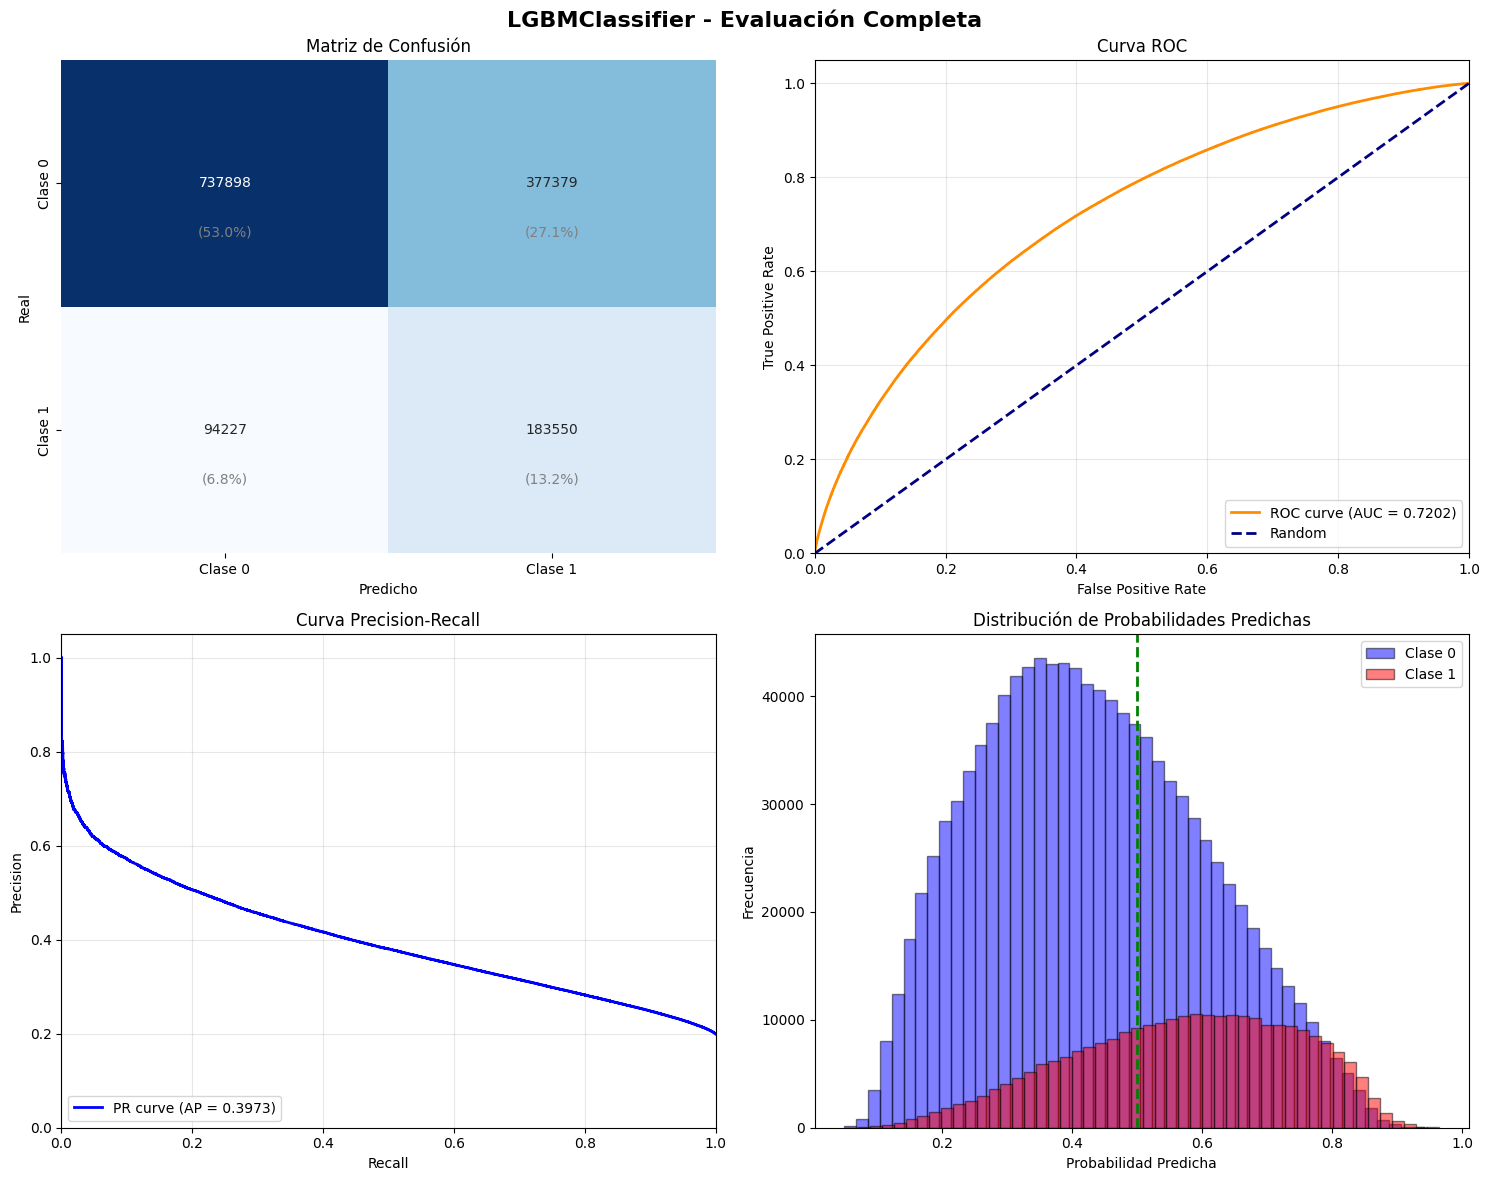


💾 Modelo guardado: lgbm_production_model.pkl
💾 Hiperparámetros guardados: lgbm_production_best_params.txt
💾 Métricas guardadas: lgbm_production_metrics.txt

✅ ¡Pipeline completado exitosamente!


In [28]:
if __name__ == "__main__":
    # Crear pipeline
    pipeline = LGBMProductionScaler(
        categorical_columns=categorical_columns,
        numerical_columns=numerical_columns,
        test_size=0.2,
        tune_fraction=0.10,
        apply_undersampling=True,
        optimize_memory=True,
        random_state=42
    )

    # 1. Preparar datos
    pipeline.prepare_data(X, y)

    # 2. Optimizar hiperparámetros (puedes elegir: 'auc', 'f1', 'precision', 'recall')
    pipeline.optimize_hyperparameters(n_trials=30, optimize_for='auc', n_jobs=-1)

    # 3. Entrenar modelo final
    pipeline.train_final_model(n_jobs=-1)

    # 4. Evaluar
    pipeline.evaluate_model(save_plots=True)

    # 5. Guardar
    pipeline.save_model_and_results(prefix='lgbm_production')

    print("\n✅ ¡Pipeline completado exitosamente!")

***CatBoost - Entrenamiento a Gran Escala
Optimizado para ~7 millones de registros con manejo nativo de categóricas***

In [16]:
# @title
class CatBoostProductionScaler:
    """
    Clase para entrenar CatBoost a escala de producción
    Aprovecha el manejo nativo de categóricas y capacidades de streaming
    """

    def __init__(self, categorical_columns, numerical_columns,
                 test_size=0.2, tune_fraction=0.10, apply_undersampling=True,
                 optimize_memory=True, random_state=42):
        """
        Parameters:
        -----------
        categorical_columns : list
            Columnas categóricas (CatBoost las maneja nativamente)
        numerical_columns : list
            Columnas numéricas
        test_size : float
            Proporción del conjunto de prueba
        tune_fraction : float
            Fracción para optimización de hiperparámetros
        apply_undersampling : bool
            Si True, aplica RandomUnderSampler
        optimize_memory : bool
            Si True, optimiza tipos de datos
        random_state : int
            Semilla aleatoria
        """
        self.categorical_columns = list(categorical_columns)
        self.numerical_columns = list(numerical_columns)
        self.all_columns = self.categorical_columns + self.numerical_columns
        self.test_size = test_size
        self.tune_fraction = tune_fraction
        self.apply_undersampling = apply_undersampling
        self.optimize_memory = optimize_memory
        self.random_state = random_state

        # Índices de features categóricas
        self.cat_features_idx = [i for i, col in enumerate(self.all_columns)
                                 if col in self.categorical_columns]

        # Balanceador
        self.rus = RandomUnderSampler(random_state=random_state, sampling_strategy=1)

        # Resultados
        self.best_params = None
        self.best_model = None
        self.metrics = {}

    def _optimize_dataframe_memory(self, df):
        """Optimiza el uso de memoria del DataFrame"""
        if not self.optimize_memory:
            return df

        print("Optimizando tipos de datos para reducir memoria...")
        mem_before = df.memory_usage(deep=True).sum() / 1024**2

        df = df.copy()

        # Optimizar columnas numéricas
        for col in self.numerical_columns:
            if col in df.columns:
                col_type = df[col].dtype
                if col_type == 'float64':
                    df[col] = df[col].astype('float32')
                elif col_type == 'int64':
                    col_min = df[col].min()
                    col_max = df[col].max()
                    if col_min >= -128 and col_max <= 127:
                        df[col] = df[col].astype('int8')
                    elif col_min >= -32768 and col_max <= 32767:
                        df[col] = df[col].astype('int16')
                    elif col_min >= -2147483648 and col_max <= 2147483647:
                        df[col] = df[col].astype('int32')

        # Columnas categóricas como 'category'
        for col in self.categorical_columns:
            if col in df.columns:
                df[col] = df[col].astype('category')

        mem_after = df.memory_usage(deep=True).sum() / 1024**2
        print(f"  Memoria reducida: {mem_before:.2f} MB → {mem_after:.2f} MB ({100*(mem_before-mem_after)/mem_before:.1f}% ahorro)")

        return df

    def _get_memory_usage(self):
        """Obtiene el uso actual de memoria"""
        process = psutil.Process(os.getpid())
        mem_info = process.memory_info()
        return mem_info.rss / 1024**2  # MB

    def prepare_data(self, X, y, verbose=True):
        """Prepara los datos: optimización, split y balanceo (sin preprocesamiento)"""
        if verbose:
            print("="*70)
            print("PREPARACIÓN DE DATOS PARA CATBOOST")
            print("="*70)
            print(f"Shape original: {X.shape}")
            print(f"Memoria inicial: {self._get_memory_usage():.1f} MB")

        # Seleccionar solo columnas necesarias
        X = X[self.all_columns].copy()

        # Optimizar memoria
        X = self._optimize_dataframe_memory(X)
        y = np.array(y, dtype='int8')

        if verbose:
            print(f"Distribución de clases: {dict(zip(*np.unique(y, return_counts=True)))}")

        # Split train/test
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=y
        )

        # Resetear índices
        X_train = X_train.reset_index(drop=True)
        X_test = X_test.reset_index(drop=True)
        y_train = np.array(y_train)
        y_test = np.array(y_test)

        if verbose:
            print(f"\nTrain: {len(X_train):,} muestras")
            print(f"Test: {len(X_test):,} muestras")

        # Balancear
        if self.apply_undersampling:
            if verbose:
                print("Aplicando RandomUnderSampler...")
            X_train, y_train = self.rus.fit_resample(X_train, y_train)
            X_train = X_train.reset_index(drop=True)
            y_train = np.array(y_train, dtype='int8')
            if verbose:
                print(f"Train balanceado: {len(y_train):,} muestras")

        # Crear subset para tuning
        n_tune = int(len(X_train) * self.tune_fraction)
        idx_tune = np.random.RandomState(self.random_state).choice(
            len(X_train), n_tune, replace=False
        )
        idx_all = np.arange(len(X_train))
        idx_val = np.setdiff1d(idx_all, idx_tune)

        X_tune = X_train.iloc[idx_tune].reset_index(drop=True)
        y_tune = y_train[idx_tune]
        X_val = X_train.iloc[idx_val].reset_index(drop=True)
        y_val = y_train[idx_val]

        self.data = {
            'X_train_full': X_train,
            'y_train_full': y_train,
            'X_tune': X_tune,
            'y_tune': y_tune,
            'X_val': X_val,
            'y_val': y_val,
            'X_test': X_test,
            'y_test': y_test
        }

        if verbose:
            print(f"Tune subset: {len(y_tune):,} muestras")
            print(f"Validation: {len(y_val):,} muestras")
            print(f"Memoria actual: {self._get_memory_usage():.1f} MB")
            print(f"Features categóricas: {len(self.cat_features_idx)}")

        # Limpiar memoria
        del X_train, X_test
        gc.collect()

        return self.data

    def optimize_hyperparameters(self, n_trials=50, optimize_for='auc',
                                  thread_count=-1, use_gpu=False):
        """
        Optimiza hiperparámetros usando Optuna

        Parameters:
        -----------
        n_trials : int
            Número de trials de Optuna
        optimize_for : str
            Métrica a optimizar: 'auc', 'f1', 'precision', 'recall'
        thread_count : int
            Número de threads (-1 = todos disponibles)
        use_gpu : bool
            Si True, usa GPU (requiere catboost-gpu)
        """
        print("="*70)
        print("OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA")
        print("="*70)
        print(f"Trials: {n_trials}")
        print(f"Optimizando para: {optimize_for.upper()}")
        print(f"Datos de tuning: {len(self.data['y_tune']):,} muestras")
        print(f"GPU: {'Activado' if use_gpu else 'Desactivado'}")

        start_time = time.time()
        mem_before = self._get_memory_usage()

        # Crear Pools de CatBoost (eficiente en memoria)
        train_pool = Pool(
            data=self.data['X_tune'],
            label=self.data['y_tune'],
            cat_features=self.cat_features_idx
        )

        val_pool = Pool(
            data=self.data['X_val'],
            label=self.data['y_val'],
            cat_features=self.cat_features_idx
        )

        def objective(trial):
            params = {
                "iterations": trial.suggest_int("iterations", 100, 1000, step=100),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "depth": trial.suggest_int("depth", 4, 10),
                "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
                "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
                "random_strength": trial.suggest_float("random_strength", 0.0, 1.0),
                "border_count": trial.suggest_categorical("border_count", [32, 64, 128, 254]),
                "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
                "random_state": self.random_state,
                "verbose": 0,
                "thread_count": thread_count,
                "task_type": "GPU" if use_gpu else "CPU"
            }

            model = CatBoostClassifier(**params)
            model.fit(
                train_pool,
                eval_set=val_pool,
                early_stopping_rounds=50,
                verbose=False
            )

            y_pred = model.predict(self.data['X_val'])
            y_pred_proba = model.predict_proba(self.data['X_val'])[:, 1]

            # Calcular métrica según optimize_for
            if optimize_for == 'auc':
                return roc_auc_score(self.data['y_val'], y_pred_proba)
            elif optimize_for == 'f1':
                _, _, f1, _ = precision_recall_fscore_support(
                    self.data['y_val'], y_pred, average='binary', pos_label=1
                )
                return f1
            elif optimize_for == 'precision':
                prec, _, _, _ = precision_recall_fscore_support(
                    self.data['y_val'], y_pred, average='binary', pos_label=1
                )
                return prec
            elif optimize_for == 'recall':
                _, rec, _, _ = precision_recall_fscore_support(
                    self.data['y_val'], y_pred, average='binary', pos_label=1
                )
                return rec
            else:
                raise ValueError(f"optimize_for='{optimize_for}' no soportado")

        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

        elapsed_time = time.time() - start_time
        mem_after = self._get_memory_usage()

        self.best_params = study.best_params
        self.best_params.update({
            "random_state": self.random_state,
            "verbose": 0,
            "thread_count": thread_count,
            "task_type": "GPU" if use_gpu else "CPU"
        })

        print(f"\n✅ Optimización completada en {timedelta(seconds=int(elapsed_time))}")
        print(f"Mejor {optimize_for.upper()}: {study.best_value:.4f}")
        print(f"RAM usada: {mem_after - mem_before:.1f} MB")
        print(f"\nMejores hiperparámetros:")
        for param, value in study.best_params.items():
            print(f"  {param}: {value}")

        return self.best_params

    def train_final_model(self, thread_count=-1, use_gpu=False):
        """Entrena el modelo final con todos los datos de entrenamiento"""
        print("\n" + "="*70)
        print("ENTRENAMIENTO DEL MODELO FINAL")
        print("="*70)

        if self.best_params is None:
            raise ValueError("Primero debes ejecutar optimize_hyperparameters()")

        print(f"Usando {len(self.data['y_train_full']):,} muestras de entrenamiento")

        start_time = time.time()

        # Crear Pool para entrenamiento eficiente
        train_pool = Pool(
            data=self.data['X_train_full'],
            label=self.data['y_train_full'],
            cat_features=self.cat_features_idx
        )

        # Entrenar con todos los datos
        self.best_model = CatBoostClassifier(**self.best_params)
        self.best_model.fit(train_pool, verbose=False)

        elapsed_time = time.time() - start_time

        print(f"✅ Modelo entrenado en {timedelta(seconds=int(elapsed_time))}")

        return self.best_model

    def evaluate_model(self, save_plots=True):
        """Evalúa el modelo final y genera métricas completas"""
        print("\n" + "="*70)
        print("EVALUACIÓN COMPLETA DEL MODELO")
        print("="*70)

        if self.best_model is None:
            raise ValueError("Primero debes ejecutar train_final_model()")

        # Predicciones
        y_pred = self.best_model.predict(self.data['X_test'])
        y_pred_proba = self.best_model.predict_proba(self.data['X_test'])[:, 1]
        y_test = self.data['y_test']

        # Métricas principales
        auc_score = roc_auc_score(y_test, y_pred_proba)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average='binary', pos_label=1
        )
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        # Métricas adicionales
        avg_precision = average_precision_score(y_test, y_pred_proba)

        self.metrics = {
            'AUC': auc_score,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'Average Precision': avg_precision,
            'True Negatives': tn,
            'False Positives': fp,
            'False Negatives': fn,
            'True Positives': tp,
            'Accuracy': (tp + tn) / (tp + tn + fp + fn),
            'Specificity': tn / (tn + fp),
            'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0
        }

        # Imprimir métricas
        print("\n📊 MÉTRICAS EN TEST SET:")
        print("="*70)
        for metric, value in self.metrics.items():
            if isinstance(value, float):
                print(f"{metric:25} {value:.4f}")
            else:
                print(f"{metric:25} {value:,}")

        # Reporte de clasificación
        print("\n" + "="*70)
        print("REPORTE DE CLASIFICACIÓN")
        print("="*70)
        print(classification_report(y_test, y_pred, target_names=['Clase 0', 'Clase 1']))

        # Feature Importance
        feature_importance = self.best_model.get_feature_importance()
        feature_names = self.all_columns

        print("\n" + "="*70)
        print("TOP 10 FEATURES MÁS IMPORTANTES")
        print("="*70)
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': feature_importance
        }).sort_values('importance', ascending=False).head(10)
        print(importance_df.to_string(index=False))

        # Visualizaciones
        if save_plots:
            self._plot_results(y_test, y_pred, y_pred_proba, feature_importance, feature_names)

        return self.metrics

    def _plot_results(self, y_test, y_pred, y_pred_proba, feature_importance, feature_names):
        """Genera visualizaciones completas"""
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

        fig.suptitle('CatBoost - Evaluación Completa', fontsize=16, fontweight='bold')

        # 1. Matriz de Confusión
        ax1 = fig.add_subplot(gs[0, 0])
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
        ax1.set_title('Matriz de Confusión')
        ax1.set_ylabel('Real')
        ax1.set_xlabel('Predicho')
        ax1.set_xticklabels(['Clase 0', 'Clase 1'])
        ax1.set_yticklabels(['Clase 0', 'Clase 1'])

        total = cm.sum()
        for i in range(2):
            for j in range(2):
                percentage = cm[i, j] / total * 100
                ax1.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)',
                        ha='center', va='center', fontsize=10, color='gray')

        # 2. Curva ROC
        ax2 = fig.add_subplot(gs[0, 1])
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)

        ax2.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (AUC = {roc_auc:.4f})')
        ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        ax2.set_xlim([0.0, 1.0])
        ax2.set_ylim([0.0, 1.05])
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.set_title('Curva ROC')
        ax2.legend(loc="lower right")
        ax2.grid(True, alpha=0.3)

        # 3. Precision-Recall Curve
        ax3 = fig.add_subplot(gs[0, 2])
        precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
        avg_precision = average_precision_score(y_test, y_pred_proba)

        ax3.plot(recall, precision, color='blue', lw=2,
                label=f'PR curve (AP = {avg_precision:.4f})')
        ax3.set_xlabel('Recall')
        ax3.set_ylabel('Precision')
        ax3.set_title('Curva Precision-Recall')
        ax3.legend(loc="lower left")
        ax3.grid(True, alpha=0.3)
        ax3.set_xlim([0.0, 1.0])
        ax3.set_ylim([0.0, 1.05])

        # 4. Distribución de Probabilidades
        ax4 = fig.add_subplot(gs[1, 0])
        ax4.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.5,
                label='Clase 0', color='blue', edgecolor='black')
        ax4.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.5,
                label='Clase 1', color='red', edgecolor='black')
        ax4.set_xlabel('Probabilidad Predicha')
        ax4.set_ylabel('Frecuencia')
        ax4.set_title('Distribución de Probabilidades')
        ax4.legend()
        ax4.axvline(x=0.5, color='green', linestyle='--', linewidth=2)

        # 5. Feature Importance (Top 15)
        ax5 = fig.add_subplot(gs[1:, 1:])
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': feature_importance
        }).sort_values('importance', ascending=False).head(15)

        ax5.barh(range(len(importance_df)), importance_df['importance'], color='steelblue')
        ax5.set_yticks(range(len(importance_df)))
        ax5.set_yticklabels(importance_df['feature'])
        ax5.set_xlabel('Importancia')
        ax5.set_title('Top 15 Features Más Importantes')
        ax5.invert_yaxis()
        ax5.grid(axis='x', alpha=0.3)

        plt.savefig('catboost_evaluation_complete.png', dpi=300, bbox_inches='tight')
        print(f"\n📊 Gráficos guardados en: catboost_evaluation_complete.png")
        plt.show()

    def save_model_and_results(self, prefix='catboost_production'):
        """Guarda el modelo y los resultados"""
        # Guardar modelo (CatBoost tiene su propio formato)
        model_filename = f'{prefix}_model.cbm'
        self.best_model.save_model(model_filename)
        print(f"\n💾 Modelo guardado: {model_filename}")

        # Guardar hiperparámetros
        params_filename = f'{prefix}_best_params.txt'
        with open(params_filename, 'w') as f:
            f.write("MEJORES HIPERPARÁMETROS - CatBoost\n")
            f.write("="*50 + "\n\n")
            for param, value in self.best_params.items():
                f.write(f"{param}: {value}\n")
        print(f"💾 Hiperparámetros guardados: {params_filename}")

        # Guardar métricas
        metrics_filename = f'{prefix}_metrics.txt'
        with open(metrics_filename, 'w') as f:
            f.write("MÉTRICAS DEL MODELO - CatBoost\n")
            f.write("="*50 + "\n\n")
            for metric, value in self.metrics.items():
                if isinstance(value, float):
                    f.write(f"{metric}: {value:.4f}\n")
                else:
                    f.write(f"{metric}: {value:,}\n")
        print(f"💾 Métricas guardadas: {metrics_filename}")

PREPARACIÓN DE DATOS PARA CATBOOST
Shape original: (6965266, 15)
Memoria inicial: 4937.9 MB
Optimizando tipos de datos para reducir memoria...
  Memoria reducida: 1454.73 MB → 292.33 MB (79.9% ahorro)
Distribución de clases: {np.int8(0): np.int64(5576380), np.int8(1): np.int64(1388886)}

Train: 5,572,212 muestras
Test: 1,393,054 muestras
Aplicando RandomUnderSampler...
Train balanceado: 2,222,218 muestras
Tune subset: 111,110 muestras
Validation: 2,111,108 muestras
Memoria actual: 5364.1 MB
Features categóricas: 3
OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA
Trials: 30
Optimizando para: AUC
Datos de tuning: 111,110 muestras
GPU: Activado


  0%|          | 0/30 [00:00<?, ?it/s]


✅ Optimización completada en 0:28:41
Mejor AUC: 0.7038
RAM usada: 267.0 MB

Mejores hiperparámetros:
  iterations: 1000
  learning_rate: 0.03409084179450089
  depth: 7
  l2_leaf_reg: 3.2316587311051195
  bagging_temperature: 0.050816414129436605
  random_strength: 0.5102058739599383
  border_count: 254
  min_data_in_leaf: 20

ENTRENAMIENTO DEL MODELO FINAL
Usando 2,222,218 muestras de entrenamiento
✅ Modelo entrenado en 0:04:49

EVALUACIÓN COMPLETA DEL MODELO

📊 MÉTRICAS EN TEST SET:
AUC                       0.7162
Precision                 0.3230
Recall                    0.6621
F1-Score                  0.4342
Average Precision         0.3902
True Negatives            729,778
False Positives           385,499
False Negatives           93,853
True Positives            183,924
Accuracy                  0.6559
Specificity               0.6543
NPV                       0.8860

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

     Clase 0       0.89      0

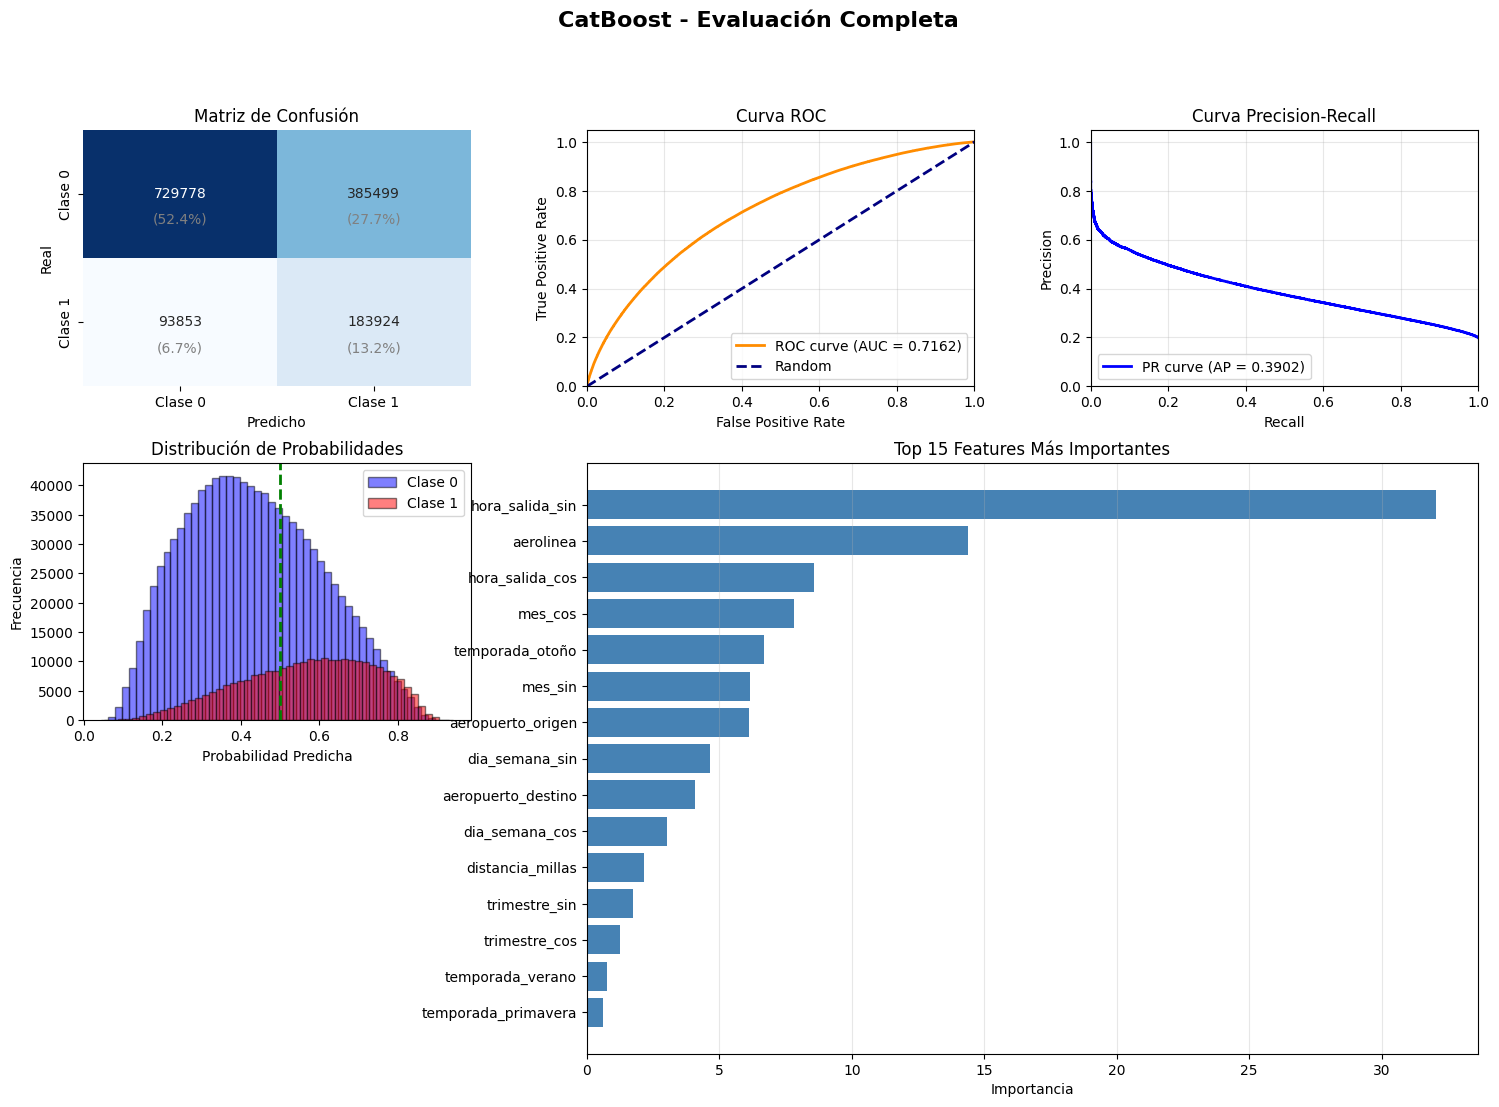


💾 Modelo guardado: catboost_production_model.cbm
💾 Hiperparámetros guardados: catboost_production_best_params.txt
💾 Métricas guardadas: catboost_production_metrics.txt


In [17]:
if __name__ == "__main__":
    # Crear pipeline
    pipeline = CatBoostProductionScaler(
        categorical_columns=categorical_columns,
        numerical_columns=numerical_columns,
        test_size=0.2,
        tune_fraction=0.05,
        apply_undersampling=True,
        optimize_memory=True,
        random_state=42
    )

    # 1. Preparar datos
    pipeline.prepare_data(X, y)

    # 2. Optimizar hiperparámetros
    pipeline.optimize_hyperparameters(
        n_trials=30,
        optimize_for='auc',  # Opciones: 'auc', 'f1', 'precision', 'recall'
        thread_count=-1,
        use_gpu=True  # Cambiar a True si tienes GPU
    )

    # 3. Entrenar modelo final
    pipeline.train_final_model(thread_count=-1, use_gpu=True)

    # 4. Evaluar
    pipeline.evaluate_model(save_plots=True)

    # 5. Guardar
    pipeline.save_model_and_results(prefix='catboost_production')